# 부산광역시 대중교통 노선 분석
**통행사슬 알고리즘을 활용한 이용자 중심 대중교통 노선 분석 (KAIA 2단계)**

---

## 분석 목차
1. 데이터 로드 및 전처리
2. 버스 노선 네트워크 분석
3. 공간 데이터 분석 (50m 격자, 집계구, 정류소)
4. 대중교통 공급 지표 산출
5. POI 기반 잠재수요 분석
6. 교통카드 거래내역 분석 (샘플)
7. 시각화 및 결과 요약

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 기본 경로 (Windows PC)
BASE = r'C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터'

print('환경 설정 완료')
print(f'작업 경로: {BASE}')

환경 설정 완료
작업 경로: C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터
환경 설정 완료
작업 경로: C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터
환경 설정 완료
작업 경로: C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터
환경 설정 완료
작업 경로: C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터


---
## 1. 데이터 로드 및 전처리

### 1.1 버스노선 데이터

In [2]:
# 버스노선.csv 로드
bus_routes = pd.read_csv(f'{BASE}/버스노선.csv', encoding='utf-8-sig')
bus_routes.columns = bus_routes.columns.str.strip().str.replace('\ufeff', '')

print(f'총 행수: {len(bus_routes):,}')
print(f'고유 노선 수: {bus_routes["노선번호"].nunique()}')
print(f'고유 정류소 수: {bus_routes["정류소ID"].nunique()}')
print(f'\n컬럼: {list(bus_routes.columns)}')
print(f'\n결측치:\n{bus_routes.isnull().sum()}')
bus_routes.head()

총 행수: 24,576
고유 노선 수: 326
고유 정류소 수: 8510

컬럼: ['노선번호', '정류소순번', '정류소명', '시', '군.구', '동', 'GPS_X', 'GPX_Y', 'ARS ID', '정류소ID']

결측치:
노선번호         0
정류소순번        0
정류소명         0
시            4
군.구       6912
동         6887
GPS_X        0
GPX_Y        0
ARS ID    7103
정류소ID        0
dtype: int64


,노선번호,정류소순번,정류소명,시,군.구,동,GPS_X,GPX_Y,ARS ID,정류소ID
0,10,1,연제공용버스차고지,부산광역시,NaN,NaN,129.053194,35.185229,13179,50000001059
1,10,2,초읍고개,부산광역시,NaN,NaN,129.054089,35.185475,13183,50000002492
2,10,3,개인택시조합,부산광역시,연제구,거제2동,129.055711,35.186786,13132,21130521003
3,10,4,부산의료원 정문,부산광역시,NaN,NaN,129.058971,35.187956,13186,50000003510
4,10,5,부산의료원,부산광역시,연제구,거제2동,129.060579,35.188257,13123,21130521007


총 행수: 24,576
고유 노선 수: 326
고유 정류소 수: 8510

컬럼: ['노선번호', '정류소순번', '정류소명', '시', '군.구', '동', 'GPS_X', 'GPX_Y', 'ARS ID', '정류소ID']

결측치:
노선번호         0
정류소순번        0
정류소명         0
시            4
군.구       6912
동         6887
GPS_X        0
GPX_Y        0
ARS ID    7103
정류소ID        0
dtype: int64


,노선번호,정류소순번,정류소명,시,군.구,동,GPS_X,GPX_Y,ARS ID,정류소ID
0,10,1,연제공용버스차고지,부산광역시,NaN,NaN,129.053194,35.185229,13179,50000001059
1,10,2,초읍고개,부산광역시,NaN,NaN,129.054089,35.185475,13183,50000002492
2,10,3,개인택시조합,부산광역시,연제구,거제2동,129.055711,35.186786,13132,21130521003
3,10,4,부산의료원 정문,부산광역시,NaN,NaN,129.058971,35.187956,13186,50000003510
4,10,5,부산의료원,부산광역시,연제구,거제2동,129.060579,35.188257,13123,21130521007


총 행수: 24,576
고유 노선 수: 326
고유 정류소 수: 8510

컬럼: ['노선번호', '정류소순번', '정류소명', '시', '군.구', '동', 'GPS_X', 'GPX_Y', 'ARS ID', '정류소ID']

결측치:
노선번호         0
정류소순번        0
정류소명         0
시            4
군.구       6912
동         6887
GPS_X        0
GPX_Y        0
ARS ID    7103
정류소ID        0
dtype: int64


,노선번호,정류소순번,정류소명,시,군.구,동,GPS_X,GPX_Y,ARS ID,정류소ID
0,10,1,연제공용버스차고지,부산광역시,NaN,NaN,129.053194,35.185229,13179,50000001059
1,10,2,초읍고개,부산광역시,NaN,NaN,129.054089,35.185475,13183,50000002492
2,10,3,개인택시조합,부산광역시,연제구,거제2동,129.055711,35.186786,13132,21130521003
3,10,4,부산의료원 정문,부산광역시,NaN,NaN,129.058971,35.187956,13186,50000003510
4,10,5,부산의료원,부산광역시,연제구,거제2동,129.060579,35.188257,13123,21130521007


총 행수: 24,576
고유 노선 수: 326
고유 정류소 수: 8510

컬럼: ['노선번호', '정류소순번', '정류소명', '시', '군.구', '동', 'GPS_X', 'GPX_Y', 'ARS ID', '정류소ID']

결측치:
노선번호         0
정류소순번        0
정류소명         0
시            4
군.구       6912
동         6887
GPS_X        0
GPX_Y        0
ARS ID    7103
정류소ID        0
dtype: int64


,노선번호,정류소순번,정류소명,시,군.구,동,GPS_X,GPX_Y,ARS ID,정류소ID
0,10,1,연제공용버스차고지,부산광역시,NaN,NaN,129.053194,35.185229,13179,50000001059
1,10,2,초읍고개,부산광역시,NaN,NaN,129.054089,35.185475,13183,50000002492
2,10,3,개인택시조합,부산광역시,연제구,거제2동,129.055711,35.186786,13132,21130521003
3,10,4,부산의료원 정문,부산광역시,NaN,NaN,129.058971,35.187956,13186,50000003510
4,10,5,부산의료원,부산광역시,연제구,거제2동,129.060579,35.188257,13123,21130521007


In [3]:
# 노선 유형 분류
def classify_route(name):
    name = str(name)
    if '심야' in name:
        return '심야버스'
    elif '아침' in name or '출' in name:
        return '출퇴근버스'
    elif name.startswith(('1001','1002','1003','1004')):
        return '급행버스'
    elif any(gu in name for gu in ['구', '동', '읍']):
        return '마을버스'
    else:
        # 숫자만 있는 노선 = 시내버스
        try:
            int(name)
            return '시내버스'
        except:
            return '마을버스'

route_list = bus_routes.groupby('노선번호').agg(
    정류소수=('정류소순번', 'max'),
    시작정류소=('정류소명', 'first'),
    종료정류소=('정류소명', 'last')
).reset_index()

route_list['노선유형'] = route_list['노선번호'].apply(classify_route)

print('=== 노선 유형별 현황 ===')
print(route_list['노선유형'].value_counts())
print(f'\n노선당 평균 정류소 수: {route_list["정류소수"].mean():.1f}')
print(f'노선당 최소 정류소 수: {route_list["정류소수"].min()}')
print(f'노선당 최대 정류소 수: {route_list["정류소수"].max()}')

=== 노선 유형별 현황 ===
노선유형
마을버스     178
시내버스     125
심야버스      15
급행버스       4
출퇴근버스      4
Name: count, dtype: int64

노선당 평균 정류소 수: 75.4
노선당 최소 정류소 수: 4
노선당 최대 정류소 수: 172


### 1.2 노선별 정류장 현황 (2025, 영문명 포함)

In [4]:
# 노선별 정류장 현황 (HTML 형식 xls)
station_2025 = pd.read_html(
    f'{BASE}/노선별 정류장 현황(2025)_20250912.xls', 
    encoding='euc-kr'
)[0]
station_2025.columns = station_2025.iloc[0]
station_2025 = station_2025.iloc[1:].reset_index(drop=True)

print(f'총 행수: {len(station_2025):,}')
print(f'컬럼: {list(station_2025.columns)}')
print(f'\n영문명 결측률: {station_2025["영문명"].isna().mean()*100:.1f}%')
station_2025.head()

총 행수: 24,576
컬럼: ['노선번호', '정류소순번', '정류소명', '영문명', '시', '군.구', '동', 'GPS_X', 'GPX_Y', 'ARS ID', '정류소ID']

영문명 결측률: 34.2%


,노선번호,정류소순번,정류소명,영문명,시,군.구,동,GPS_X,GPX_Y,ARS ID,정류소ID
0,10,1,연제공용버스차고지,Yeonje Bus Garage,부산광역시,NaN,NaN,129.053193775795,35.18522890161,13179,50000001059
1,10,2,초읍고개,Choeup Gogae,부산광역시,NaN,NaN,129.054089015583,35.18547513335,13183,50000002492
2,10,3,개인택시조합,Busan Private Taxi Association,부산광역시,연제구,거제2동,129.05571054097,35.18678578854,13132,21130521003
3,10,4,부산의료원 정문,Busan Medical Center Main gate,부산광역시,NaN,NaN,129.058971124482,35.187956289965,13186,50000003510
4,10,5,부산의료원,Busan Medical Center,부산광역시,연제구,거제2동,129.060579229391,35.188256738213,13123,21130521007


### 1.3 공간 데이터 로드

In [5]:
# 50m 격자 데이터
grid_50m = gpd.read_file(f'{BASE}/50m_grid/busan_50cell_v21.shp')
print(f'=== 50m 격자 ===')
print(f'  행: {len(grid_50m):,}, CRS: {grid_50m.crs}')
print(f'  컬럼: {list(grid_50m.columns)}')

# 버스 정류소 SHP
bus_stops_shp = gpd.read_file(f'{BASE}/부산광역시_버스 정류소 정보(SHP)_20250121/tl_bus_station_info.shp')
print(f'\n=== 버스 정류소 ===')
print(f'  행: {len(bus_stops_shp):,}, CRS: {bus_stops_shp.crs}')
print(f'  컬럼: {list(bus_stops_shp.columns)}')

# 집계구 경계
census = gpd.read_file(f'{BASE}/집계구경계/집계구경계.shp')
print(f'\n=== 집계구 경계 ===')
print(f'  행: {len(census):,}, CRS: {census.crs}')
print(f'  컬럼: {list(census.columns)}')

=== 50m 격자 ===
  행: 310,241, CRS: EPSG:5179
  컬럼: ['id', 'geometry']

=== 버스 정류소 ===
  행: 8,522, CRS: EPSG:4326
  컬럼: ['arsno', 'bstopid', 'bstopnm', 'gpsx', 'gpsy', 'stoptype', 'geometry']

=== 집계구 경계 ===
  행: 6,802, CRS: EPSG:5179
  컬럼: ['BASE_DATE', 'ADM_CD', 'TOT_REG_CD', 'geometry']


In [6]:
# CRS 통일 (EPSG:5179 기준)
TARGET_CRS = 'EPSG:5179'

if bus_stops_shp.crs.to_epsg() != 5179:
    bus_stops_shp = bus_stops_shp.to_crs(TARGET_CRS)
    print('버스 정류소: EPSG:4326 → EPSG:5179 변환 완료')

if grid_50m.crs.to_epsg() != 5179:
    grid_50m = grid_50m.to_crs(TARGET_CRS)
    
if census.crs.to_epsg() != 5179:
    census = census.to_crs(TARGET_CRS)

print(f'\n모든 레이어 CRS: {TARGET_CRS}')
print(f'  50m 격자 bounds: {grid_50m.total_bounds}')
print(f'  버스 정류소 bounds: {bus_stops_shp.total_bounds}')
print(f'  집계구 bounds: {census.total_bounds}')

버스 정류소: EPSG:4326 → EPSG:5179 변환 완료

모든 레이어 CRS: EPSG:5179
  50m 격자 bounds: [1115100. 1655350. 1164000. 1711700.]
  버스 정류소 bounds: [1104514.36837078 1656054.69304084 1165681.06281614 1715824.96978448]
  집계구 bounds: [1115081.96728516 1655365.33789062 1164133.5413208  1711697.95367432]


### 1.4 POI 데이터

In [7]:
# POI 데이터 로드
poi = pd.read_csv(f'{BASE}/BUSAN_POI/부산광역시.csv', encoding='utf-8')
poi.columns = poi.columns.str.strip().str.replace('\ufeff', '')

print(f'총 POI 수: {len(poi):,}')
print(f'컬럼: {list(poi.columns)}')
print(f'\n좌표계: EPSG:5179 (x, y)')
print(f'x 범위: {poi["x(EPSG:5179)"].min():.1f} ~ {poi["x(EPSG:5179)"].max():.1f}')
print(f'y 범위: {poi["y(EPSG:5179)"].min():.1f} ~ {poi["y(EPSG:5179)"].max():.1f}')
poi.head()

총 POI 수: 487,818
컬럼: ['고유식별자 아이디', '관심지점 명칭', '관심지점 분류 설명', '자료 출처', '도로명 주소 명칭', '지번 주소 명칭', '자료수집 일시', '객체변동 일시', 'x(EPSG:5179)', 'y(EPSG:5179)']

좌표계: EPSG:5179 (x, y)
x 범위: 1114427.2 ~ 1254723.5
y 범위: 1625202.9 ~ 1711400.4


,고유식별자 아이디,관심지점 명칭,관심지점 분류 설명,자료 출처,도로명 주소 명칭,지번 주소 명칭,자료수집 일시,객체변동 일시,x(EPSG:5179),y(EPSG:5179)
0,POI01000000IUP8OT,송정중학교운동장,405002000000,행정안전부,NaN,부산광역시 강서구 송정동 1437-49,2023-12-01,2025-01-14,1122276.908,1679855.915
1,POI01000000J00GJE,송정중학교,103001081500,행정안전부,NaN,부산광역시 강서구 송정동 1437-49,2023-12-31,2025-01-14,1122276.908,1679855.915
2,POI01000000J004YH,송정초등학교,103001081500,행정안전부,NaN,부산광역시 강서구 송정동 1437-49,2023-12-31,2025-01-14,1122276.908,1679855.915
3,POI01000000FGBFVC,송정중교,103001020000,국가기본도_건물,NaN,부산광역시 강서구 송정동 1437-44,2023-08-01,2025-01-14,1122294.183,1679836.255
4,POI01000000E0GOV9,철마4(창원)가변전광판,203104030000,국토교통부,NaN,부산광역시 기장군 일광읍 용천리 252-31,2021-07-20,2025-01-14,1154585.830,1699733.249


In [8]:
# POI 분류코드 매핑
import openpyxl

wb = openpyxl.load_workbook(f'{BASE}/BUSAN_POI/관심지점분류설명.xlsx')
ws = wb[wb.sheetnames[0]]

# 분류체계 파싱
poi_class = []
for i, row in enumerate(ws.iter_rows(min_row=3, values_only=True), 3):
    poi_class.append({
        '대분류명': row[0],
        '대분류코드': row[1],
        '중분류명': row[2],
        '중분류코드': row[3],
        '소분류명': row[4],
        '소분류코드': row[5],
        '실제입력코드': str(row[15]) if row[15] else None
    })
    
poi_class_df = pd.DataFrame(poi_class)
print(f'분류코드 수: {len(poi_class_df):,}')
print(f'\n대분류 종류:')
print(poi_class_df[['대분류명','대분류코드']].drop_duplicates().to_string(index=False))

분류코드 수: 2,341

대분류 종류:
대분류명 대분류코드
 기관명   A01
 상호명   A02
  시설   A04
  지명   A05
 NaN   NaN


In [9]:
# POI에 분류명 매핑 (분류코드 앞 3자리 = 대분류+중분류)
# 부산광역시.csv의 '관심지점 분류 설명'은 실제입력코드 형태
poi['분류코드_3자리'] = poi['관심지점 분류 설명'].astype(str).str[:3]

# 대분류 매핑 테이블 생성
major_map = poi_class_df[['대분류명','대분류코드']].drop_duplicates()

# 분류코드 앞 1자리로 대분류 매핑
code_to_major = {
    '1': '기관명', '2': '산업분류', '3': '교통시설',
    '4': '공간시설', '5': '지형지물'
}
poi['분류코드_1자리'] = poi['관심지점 분류 설명'].astype(str).str[0]
poi['대분류'] = poi['분류코드_1자리'].map(code_to_major)

print('=== POI 대분류별 현황 ===')
print(poi['대분류'].value_counts())
print(f'\n자료출처별 현황:')
print(poi['자료 출처'].value_counts().head(10))

=== POI 대분류별 현황 ===
대분류
산업분류    324091
공간시설    149790
기관명      11400
지형지물      2537
Name: count, dtype: int64

자료출처별 현황:
자료 출처
소상공인진흥공단        168685
지방자치단체인허가정보      92739
국가기본도_건물         91288
행정안전부            59605
국토교통부            11049
보건복지부            10122
건강보험심사평가원         7268
국가기본도_면형도로시설      5689
국가기본도_시설구역경계      5514
국가기본도_점형도로시설      4983
Name: count, dtype: int64


In [10]:
# POI를 GeoDataFrame으로 변환
poi_valid = poi.dropna(subset=['x(EPSG:5179)', 'y(EPSG:5179)'])
poi_gdf = gpd.GeoDataFrame(
    poi_valid,
    geometry=gpd.points_from_xy(
        poi_valid['x(EPSG:5179)'].astype(float), 
        poi_valid['y(EPSG:5179)'].astype(float)
    ),
    crs=TARGET_CRS
)
print(f'POI GeoDataFrame: {len(poi_gdf):,}건')

POI GeoDataFrame: 487,818건


### 1.5 교통카드 거래내역 (샘플)

In [11]:
# 교통카드 거래내역 (parquet)
# 원본: C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터\A001_202507\A001_202507_processed.parquet

card_columns = [
    'date', 'card_type', 'card_number', 'seq', 'in_out',
    'transport_id', 'transport_name', 'station_id', 'station_name',
    'device_id', 'transaction_id', 'payment_type', 'time',
    'passenger_type', 'passenger_detail', 'passenger_count', 'station_seq'
]

card_df = pd.read_parquet(f'{BASE}/A001_202507/A001_202507_processed.parquet')

# 컬럼명이 없으면 할당
if card_df.columns.tolist()[0] == 0 or 'Unnamed' in str(card_df.columns[0]):
    # 인덱스 컬럼 제거 (첫 컬럼이 0,1,2... 인덱스인 경우)
    if len(card_df.columns) == 18:  # 인덱스 포함
        card_df = card_df.iloc[:, 1:]  # 첫 컬럼(인덱스) 제거
    card_df.columns = card_columns

print(f'=== 교통카드 거래내역 (A001_202507) ===')
print(f'행수: {len(card_df):,}')
print(f'컬럼: {list(card_df.columns)}')
print(f'\n기본 정보:')
print(f'  기간: {card_df["date"].min()} ~ {card_df["date"].max()}')
print(f'  카드 수: {card_df["card_number"].nunique():,}')
print(f'  수단: {card_df["transport_name"].unique()}')
print(f'\n메모리: {card_df.memory_usage(deep=True).sum()/1e6:.1f} MB')

# in_out 파싱: "환승횟수-승하차" (뒷자리 0=승차, 1=하차)
card_df['환승횟수'] = card_df['in_out'].astype(str).str.split('-').str[0].astype(int)
card_df['승하차'] = card_df['in_out'].astype(str).str.split('-').str[1].map({'0':'승차','1':'하차'})

# time → HH:MM 형식
card_df['time_str'] = card_df['time'].astype(str).str.zfill(4)
card_df['time_fmt'] = card_df['time_str'].str[:2] + ':' + card_df['time_str'].str[2:]
card_df['시간대'] = card_df['time_str'].str[:2].astype(int)

card_df.head()

# 수단 구분: transaction_id가 '00000000' = 지하철, 그 외 = 버스
card_df['수단'] = card_df['transaction_id'].astype(str).str.strip().apply(
    lambda x: '지하철' if x == '00000000' or x == '0' else '버스'
)

print(f'\n=== 수단 구분 (transaction_id 기반) ===')
print(f'지하철: transaction_id == 00000000')
print(f'버스: transaction_id != 00000000 (차량번호)')
print(card_df['수단'].value_counts())
print(f'\n수단별 샘플:')
for mode in card_df['수단'].unique():
    sample = card_df[card_df['수단']==mode].iloc[0]
    print(f'  {mode}: transaction_id={sample["transaction_id"]}, transport_name={sample["transport_name"]}')

# 탑승순서 = 환승횟수 + 1
card_df['탑승순서'] = card_df['환승횟수'] + 1

# 심야여부
card_df['심야여부'] = card_df['시간대'].between(0, 5)


=== 교통카드 거래내역 (A001_202507) ===
행수: 107,108,999
컬럼: ['date', 'card_type', 'card_number', 'seq', 'in_out', 'transport_id', 'transport_name', 'station_id', 'station_name', 'device_id', 'transaction_id', 'payment_type', 'time', 'passenger_type', 'passenger_detail', 'amount', 'extra_info']

기본 정보:
  기간: 2025-07-01 00:00:00 ~ 2025-07-31 00:00:00
  카드 수: 4,132,882
  수단: ['부산1호선', '부산2호선', '부산3호선', '52', '508', ..., '금정구5', '강서구6', '기장9용월', '1004(심야)', '금정구5-1']
Length: 331
Categories (331, str): ['10', '100', '100-1', '1000(급행)', ..., '해운대3-1', '해운대구3', '해운대구3-2', '해운대구7']

메모리: 4474.5 MB

=== 수단 구분 (transaction_id 기반) ===
지하철: transaction_id == 00000000
버스: transaction_id != 00000000 (차량번호)
수단
지하철    53718856
버스     53390143
Name: count, dtype: int64

수단별 샘플:
  지하철: transaction_id=00000000, transport_name=부산1호선
  버스: transaction_id=부산70자4541, transport_name=52


### 1.6 교통카드 거래내역 EDA

In [12]:
# 1.6.1 수단별 거래내역 현황
print('=== 수단별(지하철/버스) 거래내역 ===')
print(card_df['수단'].value_counts())
print(f'\ntransport_name별:')
print(card_df.groupby(['수단','transport_name']).size().reset_index(name='건수').sort_values('건수', ascending=False).head(20).to_string(index=False))

print(f'\n=== 승하차 구분 ===')
print(card_df['승하차'].value_counts())

# 수단별 하차 결측 분석
print(f'\n=== 수단별 하차 결측 분석 ===')
for mode in ['버스', '지하철']:
    sub = card_df[card_df['수단'] == mode]
    s = (sub['승하차']=='승차').sum()
    d = (sub['승하차']=='하차').sum()
    rate = (1 - d/s)*100 if s > 0 else 0
    print(f'  {mode}: 총 {len(sub):,}건, 승차 {s:,}, 하차 {d:,}, 하차결측률 {rate:.1f}%')

# 전체
total_s = (card_df['승하차']=='승차').sum()
total_d = (card_df['승하차']=='하차').sum()
print(f'  전체: 총 {len(card_df):,}건, 승차 {total_s:,}, 하차 {total_d:,}, 하차결측률 {(1-total_d/total_s)*100:.1f}%')

=== 수단별(지하철/버스) 거래내역 ===
수단
지하철    53718856
버스     53390143
Name: count, dtype: int64

transport_name별:
 수단 transport_name       건수
지하철          부산1호선 24744615
지하철          부산2호선 19155628
지하철          부산3호선  5586426
지하철          김해경전철  2656757
지하철          부산4호선  1575430
 버스             68  1019227
 버스             81   927244
 버스             87   808812
 버스             67   776825
 버스             31   770625
 버스            155   767763
 버스             16   766010
 버스             15   757723
 버스             51   717556
 버스            126   716583
 버스            169   683679
 버스             54   670534
 버스            113   622611
 버스             23   621869
 버스             33   612910

=== 승하차 구분 ===
승하차
승차    64502397
하차    42606602
Name: count, dtype: int64

=== 수단별 하차 결측 분석 ===
  버스: 총 53,390,143건, 승차 37,614,648, 하차 15,775,495, 하차결측률 58.1%
  지하철: 총 53,718,856건, 승차 26,887,749, 하차 26,831,107, 하차결측률 0.2%
  전체: 총 107,108,999건, 승차 64,502,397, 하차 42,606,602, 하차결측률 33.9%


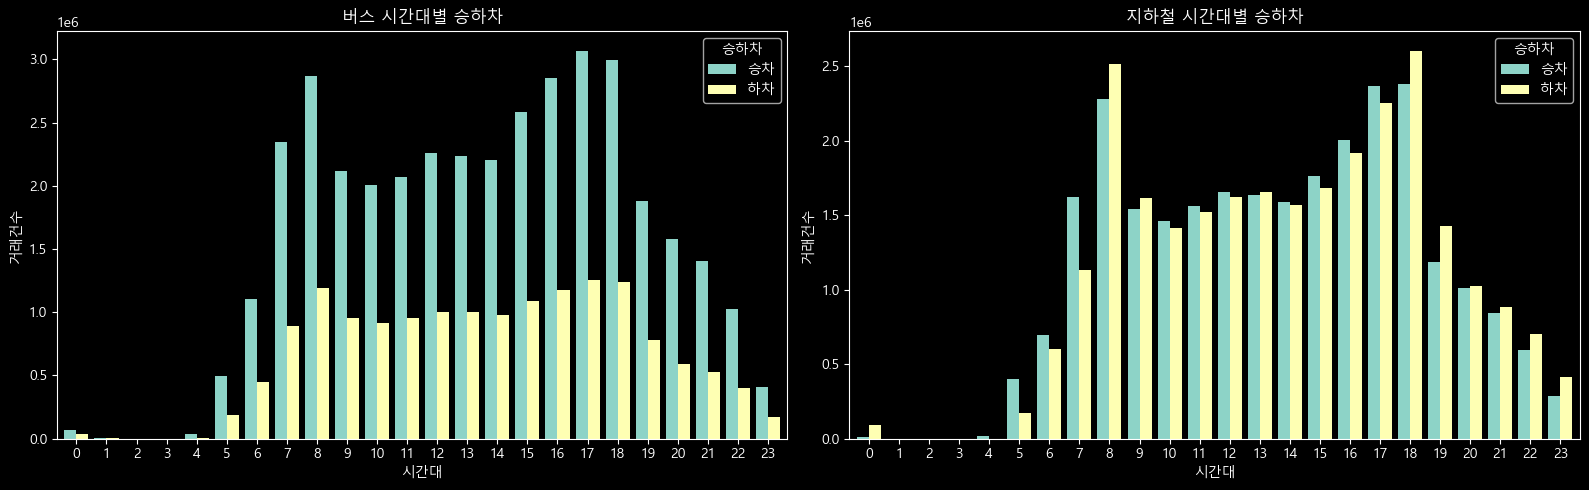

In [13]:
# 1.6.2 시간대별 이용 패턴 (수단별)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 버스
bus_hourly = card_df[card_df['수단']=='버스'].groupby(['시간대','승하차']).size().unstack(fill_value=0)
bus_hourly.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_xlabel('시간대')
axes[0].set_ylabel('거래건수')
axes[0].set_title('버스 시간대별 승하차')
axes[0].tick_params(axis='x', rotation=0)

# 지하철
subway_hourly = card_df[card_df['수단']=='지하철'].groupby(['시간대','승하차']).size().unstack(fill_value=0)
subway_hourly.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_xlabel('시간대')
axes[1].set_ylabel('거래건수')
axes[1].set_title('지하철 시간대별 승하차')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{BASE}/fig_00_hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# 1.6.3 환승 현황 (수단별)
print('=== 환승횟수별 현황 (전체) ===')
transfer = card_df.groupby('환승횟수').agg(
    거래건수=('card_number','count'),
    승차건수=('승하차', lambda x: (x=='승차').sum()),
    하차건수=('승하차', lambda x: (x=='하차').sum())
)
transfer['하차결측률'] = ((transfer['승차건수'] - transfer['하차건수']) / transfer['승차건수'] * 100).round(1)
display(transfer)

print('\n=== 수단 x 환승횟수 ===')
cross = card_df.groupby(['수단','환승횟수']).size().unstack(fill_value=0)
display(cross)

=== 환승횟수별 현황 (전체) ===


,거래건수,승차건수,하차건수,하차결측률
환승횟수,,,,
0,89027516,52511682,36515834,30.5
1,16136447,10544851,5591596,47.0
2,1945035,1445864,499171,65.5
7,1,0,1,-inf



=== 수단 x 환승횟수 ===


환승횟수,0,1,2,7
수단,,,,
버스,41493492,10263808,1632842,1
지하철,47534024,5872639,312193,0


In [15]:
# 1.6.4 수단통행량 (집계구 단위) - 정류소ID 기반
# 교통카드의 station_id와 버스노선의 정류소ID 매핑

# 승차 데이터만 추출
boarding = card_df[card_df['승하차'] == '승차'].copy()

# 정류소별 승차량
station_boarding = boarding.groupby('station_id').size().reset_index(name='승차량')
station_boarding['station_id'] = station_boarding['station_id'].astype(str).str.strip()

print(f'승차 기록 있는 정류소: {len(station_boarding):,}개')
print(f'\n승차량 상위 10 정류소:')
top_stations = station_boarding.nlargest(10, '승차량')

# station_name 매핑
name_map = card_df[['station_id','station_name']].drop_duplicates('station_id', keep='first').set_index('station_id')['station_name']
top_stations['역/정류소명'] = top_stations['station_id'].map(name_map)
print(top_stations[['station_id','역/정류소명','승차량']].to_string(index=False))

승차 기록 있는 정류소: 8,974개

승차량 상위 10 정류소:
station_id     역/정류소명     승차량
   0000119     지하철서명역 1051326
   0000219     지하철서면역  729839
   0000113     지하철부산역  688849
   0000227     지하철사상역  634700
   0000206 지하철  센텀시티역  630984
   0000102     지하철하단역  559216
   0000111    지하철남포동역  527913
   0000123    지하철연산동역  503102
   0000110    지하철자갈치역  491490
   0000120    지하철부전동역  477767


---
## 2. 버스 노선 네트워크 분석

In [16]:
# 노선 유형별 통계
route_stats = route_list.groupby('노선유형').agg(
    노선수=('노선번호', 'count'),
    평균정류소수=('정류소수', 'mean'),
    최소정류소수=('정류소수', 'min'),
    최대정류소수=('정류소수', 'max')
).round(1)

print('=== 노선 유형별 통계 ===')
route_stats

=== 노선 유형별 통계 ===


,노선수,평균정류소수,최소정류소수,최대정류소수
노선유형,,,,
급행버스,4,103.0,88,110
마을버스,178,50.9,4,154
시내버스,125,102.7,24,168
심야버스,15,116.6,71,172
출퇴근버스,4,128.8,74,168


In [17]:
# 노선별 경로 생성 (LineString) - GPS 좌표 기반
bus_routes_clean = bus_routes.dropna(subset=['GPS_X', 'GPX_Y'])
bus_routes_clean['GPS_X'] = pd.to_numeric(bus_routes_clean['GPS_X'], errors='coerce')
bus_routes_clean['GPX_Y'] = pd.to_numeric(bus_routes_clean['GPX_Y'], errors='coerce')
bus_routes_clean = bus_routes_clean.dropna(subset=['GPS_X', 'GPX_Y'])

route_lines = []
for route_no, grp in bus_routes_clean.sort_values('정류소순번').groupby('노선번호'):
    coords = list(zip(grp['GPS_X'], grp['GPX_Y']))
    if len(coords) >= 2:
        route_lines.append({
            '노선번호': route_no,
            '정류소수': len(coords),
            'geometry': LineString(coords)
        })

routes_gdf = gpd.GeoDataFrame(route_lines, crs='EPSG:4326')
# 5179로 변환하여 거리 계산
routes_gdf_5179 = routes_gdf.to_crs(TARGET_CRS)
routes_gdf_5179['노선길이_km'] = routes_gdf_5179.geometry.length / 1000

print(f'노선 경로 생성: {len(routes_gdf)}개')
print(f'평균 노선 길이: {routes_gdf_5179["노선길이_km"].mean():.1f} km')
print(f'최장 노선: {routes_gdf_5179.loc[routes_gdf_5179["노선길이_km"].idxmax(), "노선번호"]} ({routes_gdf_5179["노선길이_km"].max():.1f} km)')
print(f'최단 노선: {routes_gdf_5179.loc[routes_gdf_5179["노선길이_km"].idxmin(), "노선번호"]} ({routes_gdf_5179["노선길이_km"].min():.1f} km)')

노선 경로 생성: 326개
평균 노선 길이: 30.3 km
최장 노선: 2000 (107.2 km)
최단 노선: 부산진구8 (1.4 km)


In [18]:
# 2.1 노선 굴곡도 산출
# 정의: 정류장간 총 운행거리 / 기점~가장 먼 정류장 직선거리
# 1이면 직선, 클수록 굴곡이 심함

def calc_sinuosity(route_gdf_row):
    """노선 굴곡도 산출"""
    line = route_gdf_row.geometry
    total_length = line.length  # 총 운행거리
    
    # 기점에서 가장 먼 지점까지의 직선거리
    start = Point(line.coords[0])
    max_dist = 0
    for coord in line.coords:
        d = start.distance(Point(coord))
        if d > max_dist:
            max_dist = d
    
    if max_dist == 0:
        return np.nan
    return total_length / max_dist

routes_gdf_5179['노선굴곡도'] = routes_gdf_5179.apply(calc_sinuosity, axis=1)

print('=== 노선 굴곡도 상위 10 ===')
top_sinuosity = routes_gdf_5179.nlargest(10, '노선굴곡도')[['노선번호', '노선길이_km', '노선굴곡도']]
print(top_sinuosity.to_string(index=False))

print(f'\n평균 굴곡도: {routes_gdf_5179["노선굴곡도"].mean():.2f}')
print(f'중앙값 굴곡도: {routes_gdf_5179["노선굴곡도"].median():.2f}')

=== 노선 굴곡도 상위 10 ===
노선번호   노선길이_km    노선굴곡도
  67 38.947410 7.918526
 167 34.155739 7.597770
 520 76.118918 7.529312
  55 69.092673 7.491705
영도구5 22.067923 6.981366
 169 34.849386 6.836189
  33 45.712139 6.748813
 115 20.320672 6.724395
  70 35.652369 6.493184
3005 84.595048 6.398881

평균 굴곡도: 3.58
중앙값 굴곡도: 3.29


In [19]:
# 2.2 노선 중복도 산출
# 정의: 동일 링크를 공유하는 다른 노선의 수
# 각 정류소 쌍(link)에 몇 개 노선이 지나는지 계산

# 정류소 ID 기반 링크 생성
bus_routes_sorted = bus_routes.sort_values(['노선번호', '정류소순번'])

links = []
for route_no, grp in bus_routes_sorted.groupby('노선번호'):
    stops = grp['정류소ID'].tolist()
    for i in range(len(stops)-1):
        link = tuple(sorted([str(stops[i]), str(stops[i+1])]))
        links.append({'노선번호': route_no, 'link': link})

links_df = pd.DataFrame(links)
link_counts = links_df.groupby('link')['노선번호'].nunique().reset_index()
link_counts.columns = ['link', '공유노선수']

# 노선별 중복도 = 해당 노선의 링크들의 공유노선수 합 / 노선 총 링크 수
links_merged = links_df.merge(link_counts, on='link')
route_overlap = links_merged.groupby('노선번호').agg(
    총링크수=('link', 'count'),
    평균중복도=('공유노선수', 'mean'),
    최대중복도=('공유노선수', 'max')
).round(2).reset_index()

print('=== 노선 중복도 상위 10 ===')
print(route_overlap.nlargest(10, '평균중복도').to_string(index=False))

print(f'\n전체 평균 중복도: {route_overlap["평균중복도"].mean():.2f}')
print(f'전체 링크 수: {len(link_counts):,}')
print(f'2개 이상 노선이 공유하는 링크: {(link_counts["공유노선수"]>=2).sum():,}개 ({(link_counts["공유노선수"]>=2).mean()*100:.1f}%)')

=== 노선 중복도 상위 10 ===
    노선번호  총링크수  평균중복도  최대중복도
      26    67  12.34     33
  26(아침)    73  11.49     33
      27    79  10.81     33
      41    78   9.91     33
      81    80   9.54     27
      59   130   9.42     33
      61   128   9.39     33
      62    89   8.89     23
     134    98   8.87     33
1004(심야)   167   8.85     33

전체 평균 중복도: 3.85
전체 링크 수: 10,410
2개 이상 노선이 공유하는 링크: 4,617개 (44.4%)


---
## 3. 공간 데이터 분석

In [20]:
# 3.1 집계구 기본 통계
print('=== 집계구 경계 ===')
print(f'총 집계구 수: {len(census):,}')
print(f'\nBASE_DATE 분포: {census["BASE_DATE"].value_counts().to_dict()}')

# 행정구역코드에서 구/군 추출 (ADM_CD 앞 5자리)
census['시군구코드'] = census['ADM_CD'].astype(str).str[:5]
census['면적_km2'] = census.geometry.area / 1e6

print(f'\n시군구별 집계구 수:')
print(census['시군구코드'].value_counts().head(20))

=== 집계구 경계 ===
총 집계구 수: 6,802

BASE_DATE 분포: {'20240630': 6802}

시군구별 집계구 수:
시군구코드
21090    738
21050    719
21100    627
21080    569
21060    549
21070    517
21110    470
21150    436
21130    408
21510    380
21140    359
21120    314
21040    231
21020    221
21030    176
21010     88
Name: count, dtype: int64


In [21]:
# 3.2 정류소를 집계구에 매핑 (Spatial Join)
stops_in_census = gpd.sjoin(bus_stops_shp, census, how='left', predicate='within')

# 집계구별 정류소 수 집계
stops_per_census = stops_in_census.groupby('TOT_REG_CD').size().reset_index(name='정류소수')
census_with_stops = census.merge(stops_per_census, on='TOT_REG_CD', how='left')
census_with_stops['정류소수'] = census_with_stops['정류소수'].fillna(0).astype(int)

print('=== 집계구별 정류소 분포 ===')
print(f'정류소 0개 집계구: {(census_with_stops["정류소수"]==0).sum():,}개 ({(census_with_stops["정류소수"]==0).mean()*100:.1f}%)')
print(f'정류소 1개 이상 집계구: {(census_with_stops["정류소수"]>=1).sum():,}개')
print(f'\n정류소 수 통계:')
print(census_with_stops['정류소수'].describe().round(1))

=== 집계구별 정류소 분포 ===
정류소 0개 집계구: 4,068개 (59.8%)
정류소 1개 이상 집계구: 2,734개

정류소 수 통계:
count    6802.0
mean        1.2
std         2.8
min         0.0
25%         0.0
50%         0.0
75%         1.0
max        53.0
Name: 정류소수, dtype: float64


In [22]:
# 3.3 250m 격자 생성 (50m 격자를 5x5로 묶기)
# 50m 격자의 centroid를 250m 단위로 그룹핑
grid_50m['cx'] = grid_50m.geometry.centroid.x
grid_50m['cy'] = grid_50m.geometry.centroid.y

# 250m 격자 ID 생성 (좌하단 좌표 기준)
grid_50m['grid250_x'] = (grid_50m['cx'] // 250) * 250
grid_50m['grid250_y'] = (grid_50m['cy'] // 250) * 250
grid_50m['grid250_id'] = grid_50m['grid250_x'].astype(int).astype(str) + '_' + grid_50m['grid250_y'].astype(int).astype(str)

n_250 = grid_50m['grid250_id'].nunique()
print(f'50m 격자: {len(grid_50m):,}개')
print(f'250m 격자 (집계): {n_250:,}개')
print(f'비율: 50m {len(grid_50m)/n_250:.1f}개 → 250m 1개')

50m 격자: 310,241개
250m 격자 (집계): 13,105개
비율: 50m 23.7개 → 250m 1개


---
## 4. 대중교통 공급 지표 산출

In [23]:
# 4.1 정류장 밀도 (집계구 단위)
# 정의: 집계구 내 정류장 수 / 집계구 면적(km2)

census_with_stops['정류장밀도'] = census_with_stops['정류소수'] / census_with_stops['면적_km2']
census_with_stops['정류장밀도'] = census_with_stops['정류장밀도'].replace([np.inf, -np.inf], 0)

print('=== 정류장 밀도 (개/km2) ===')
print(census_with_stops['정류장밀도'].describe().round(1))

print(f'\n정류장 밀도 상위 10 집계구:')
top_density = census_with_stops.nlargest(10, '정류장밀도')[['TOT_REG_CD','정류소수','면적_km2','정류장밀도']]
print(top_density.to_string(index=False))

=== 정류장 밀도 (개/km2) ===
count    6802.0
mean       34.3
std        65.4
min         0.0
25%         0.0
50%         0.0
75%        49.7
max      1324.3
Name: 정류장밀도, dtype: float64

정류장 밀도 상위 10 집계구:
    TOT_REG_CD  정류소수   면적_km2       정류장밀도
21080540010005     2 0.001510 1324.327418
21050740030401     2 0.001907 1048.636163
21060510040008     1 0.001149  870.250527
21080620020604     3 0.005668  529.268804
21050640020501     2 0.004124  484.989407
21050610010101     2 0.004233  472.460279
21060590010302     2 0.004434  451.011711
21050560040103     2 0.004453  449.121557
21050800010013     1 0.002274  439.680994
21020530020101     2 0.004549  439.656473


In [24]:
# 4.2 정류장 커버리지 (400m 반경)
# 정의: 정류장 반경 400m 서비스 면적 / 집계구 총 면적

# 정류소 400m 버퍼 생성
bus_stops_buffer = bus_stops_shp.copy()
bus_stops_buffer['geometry'] = bus_stops_shp.geometry.buffer(400)

# 전체 서비스 면적 (union)
service_area = unary_union(bus_stops_buffer.geometry)

# 집계구별 커버리지
coverage_list = []
for idx, row in census.iterrows():
    intersection = row.geometry.intersection(service_area)
    coverage = intersection.area / row.geometry.area if row.geometry.area > 0 else 0
    coverage_list.append({
        'TOT_REG_CD': row['TOT_REG_CD'],
        '서비스면적': intersection.area,
        '총면적': row.geometry.area,
        '커버리지': min(coverage, 1.0)  # 1.0 cap
    })

coverage_df = pd.DataFrame(coverage_list)
census_with_stops = census_with_stops.merge(coverage_df[['TOT_REG_CD','커버리지']], on='TOT_REG_CD', how='left')

print('=== 정류장 커버리지 (400m 반경) ===')
print(coverage_df['커버리지'].describe().round(3))
print(f'\n커버리지 100% 집계구: {(coverage_df["커버리지"]>=0.99).sum():,}개')
print(f'커버리지 50% 미만 집계구: {(coverage_df["커버리지"]<0.5).sum():,}개')
print(f'커버리지 0% 집계구: {(coverage_df["커버리지"]==0).sum():,}개')

=== 정류장 커버리지 (400m 반경) ===
count    6802.000
mean        0.973
std         0.127
min         0.000
25%         1.000
50%         1.000
75%         1.000
max         1.000
Name: 커버리지, dtype: float64

커버리지 100% 집계구: 6,368개
커버리지 50% 미만 집계구: 168개
커버리지 0% 집계구: 20개


In [25]:
# 4.3 정차 노선 수 (집계구 단위)# 정류소명 기준으로 bus_routes와 bus_stops_shp 매칭stops_routes = bus_stops_shp[['bstopid', 'geometry', 'bstopnm_clean']].copy()# 정류소별 노선 수 계산 (정류소명 기준)routes_per_stop = bus_routes.groupby('정류소명_clean')['노선번호'].nunique().reset_index()routes_per_stop.columns = ['정류소명_clean', '정차노선수']# 정류소명으로 매칭stops_routes = stops_routes.merge(routes_per_stop, on='정류소명_clean', how='left')stops_routes['정차노선수'] = stops_routes['정차노선수'].fillna(0).astype(int)print(f'정차노선수 매핑: {(stops_routes["정차노선수"] > 0).sum()}/{len(stops_routes)}개 정류소')# 집계구와 공간 조인 후 정차노선수 집계stops_in_census2 = gpd.sjoin(stops_routes, census, how='inner', predicate='within')# 집계구별 총 정차노선수 (중복 제거)routes_per_census = stops_in_census2.groupby('TOT_REG_CD')['정차노선수'].sum().reset_index()routes_per_census.columns = ['TOT_REG_CD', '총정차노선수']census_with_stops = census_with_stops.merge(routes_per_census, on='TOT_REG_CD', how='left')census_with_stops['총정차노선수'] = census_with_stops['총정차노선수'].fillna(0).astype(int)print('=== 정차 노선 수 (집계구 단위) ===')print(census_with_stops['총정차노선수'].describe())print(f'\n정차노선수 상위 10 집계구:')top_routes = census_with_stops.nlargest(10, '총정차노선수')[['TOT_REG_CD', '정류소수', '총정차노선수']]print(top_routes.to_string(index=False))

---
## 5. POI 기반 잠재수요 분석

In [26]:
# 5.1 집계구별 POI 분포
poi_in_census = gpd.sjoin(poi_gdf, census, how='left', predicate='within')

poi_per_census = poi_in_census.groupby('TOT_REG_CD').agg(
    POI수=('고유식별자 아이디', 'count'),
    상업시설=('대분류', lambda x: (x=='산업분류').sum()),
    교통시설=('대분류', lambda x: (x=='교통시설').sum()),
    공간시설=('대분류', lambda x: (x=='공간시설').sum()),
    기관=('대분류', lambda x: (x=='기관명').sum())
).reset_index()

census_with_stops = census_with_stops.merge(poi_per_census, on='TOT_REG_CD', how='left')
census_with_stops['POI수'] = census_with_stops['POI수'].fillna(0).astype(int)

print('=== 집계구별 POI 분포 ===')
print(census_with_stops['POI수'].describe().round(1))

print(f'\nPOI 상위 10 집계구:')
print(census_with_stops.nlargest(10, 'POI수')[['TOT_REG_CD','POI수','상업시설','정류소수','커버리지']].to_string(index=False))

=== 집계구별 POI 분포 ===
count    6802.0
mean       71.7
std       141.6
min         0.0
25%         8.0
50%        24.0
75%        83.0
max      3442.0
Name: POI수, dtype: float64

POI 상위 10 집계구:
    TOT_REG_CD  POI수   상업시설  정류소수     커버리지
21150630010001  3442 1586.0    37 0.993624
21050520010001  2324 2158.0     8 1.000000
21090740080102  2250 2100.0    12 1.000000
21150510030001  2122  818.0    26 0.427321
21150650020004  2035  935.0    11 0.993401
21030530010001  1960 1457.0    12 0.811766
21050520020001  1709 1578.0     6 1.000000
21050520020002  1624 1492.0     6 1.000000
21510130200002  1617  868.0    10 0.277721
21080630020001  1416 1153.0     8 0.468468


In [28]:
# 5.2 잠재수요 취약지역 도출
# 조건: POI 많지만 정류소 부족한 집계구

# POI 밀도 (개/km2)
census_with_stops['POI밀도'] = census_with_stops['POI수'] / census_with_stops['면적_km2']
census_with_stops['POI밀도'] = census_with_stops['POI밀도'].replace([np.inf, -np.inf], 0)

# 잠재수요 취약지역: POI밀도 상위 25% & 커버리지 하위 25%
poi_q75 = census_with_stops['POI밀도'].quantile(0.75)
cov_q25 = census_with_stops['커버리지'].quantile(0.25)

vulnerable = census_with_stops[
    (census_with_stops['POI밀도'] >= poi_q75) & 
    (census_with_stops['커버리지'] <= cov_q25)
]

print(f'=== 잠재수요 취약지역 ===')
print(f'기준: POI밀도 >= {poi_q75:.0f} & 커버리지 <= {cov_q25:.2f}')
print(f'해당 집계구: {len(vulnerable):,}개')

if len(vulnerable) > 0:
    print(f'\n취약지역 상위 20:')
    print(vulnerable.nlargest(20, 'POI밀도')[['TOT_REG_CD','POI밀도','정류소수','커버리지']].to_string(index=False))

=== 잠재수요 취약지역 ===
기준: POI밀도 >= 3275 & 커버리지 <= 1.00
해당 집계구: 1,701개

취약지역 상위 20:
    TOT_REG_CD        POI밀도  정류소수  커버리지
21070530030006 24192.985351     5   1.0
21120590060206 22693.843046     0   1.0
21100630020102 22537.766538     0   1.0
21140570010023 20012.658788     1   1.0
21060550011401 19884.000054     0   1.0
21050520020002 19496.155073     6   1.0
21060550012802 19079.923947     0   1.0
21070530030013 19027.993120     0   1.0
21090670020001 18532.884976     3   1.0
21050610010007 18410.595825     4   1.0
21090670010003 18295.956990     1   1.0
21070530030012 16459.873663     2   1.0
21010560010007 16237.055768     0   1.0
21050820020001 15917.898412     1   1.0
21080610010001 14603.475134     2   1.0
21010570010001 14599.524041     0   1.0
21070530030001 14223.755781     0   1.0
21030660010002 14019.747569     4   1.0
21010510010002 13888.802232     1   1.0
21070700010006 13777.076359     0   1.0


---
## 5-2. 심야시간(0시~5시) 대중교통 수요 분석
교통카드 거래내역의 time 컬럼 기반 심야 시간대 필터링

In [29]:
# 심야 시간대 정의: 0시~5시 (0000~0559)
night_mask = card_df['시간대'].between(0, 5)
night_df = card_df[night_mask].copy()

print(f'=== 심야시간(0~5시) 거래 현황 ===')
print(f'전체 거래: {len(card_df):,}')
print(f'심야 거래: {len(night_df):,} ({len(night_df)/len(card_df)*100:.2f}%)')
print(f'\n심야 수단별:')
print(night_df['수단'].value_counts())
print(f'\n심야 수단 x 승하차:')
print(night_df.groupby(['수단','승하차']).size().unstack(fill_value=0))

=== 심야시간(0~5시) 거래 현황 ===
전체 거래: 107,108,999
심야 거래: 1,515,213 (1.41%)

심야 수단별:
수단
버스     823652
지하철    691561
Name: count, dtype: int64

심야 수단 x 승하차:
승하차      승차      하차
수단                 
버스   598187  225465
지하철  426868  264693


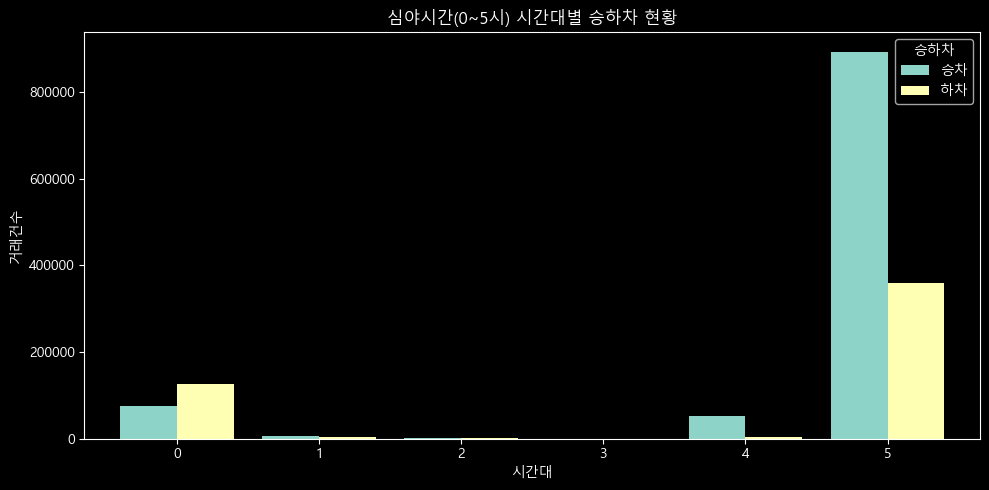

승하차      승차      하차
시간대                
0     74790  124774
1      4843    2983
2       171     256
3         5       3
4     52282    3085
5    892964  359057


In [30]:
# 5-2.1 심야 시간대별 상세 이용량
night_hourly = night_df.groupby(['시간대', '승하차']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
night_hourly.plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel('시간대')
ax.set_ylabel('거래건수')
ax.set_title('심야시간(0~5시) 시간대별 승하차 현황')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{BASE}/fig_night_01_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

print(night_hourly)

In [31]:
# 심야 승차량 상위 정류소 (정류소/역별)night_station = night_boarding.groupby(['station_id', 'station_name'])['passenger_type'].count().reset_index()night_station.columns = ['station_id', 'station_name', '심야승차량']night_station = night_station.sort_values('심야승차량', ascending=False)print(f'=== 심야 승차량 상위 30 정류소/역 (전체) ===')print(night_station.head(30)[['station_id', 'station_name', '심야승차량']].to_string(index=False))print(f'\n심야 승차 기록 있는 정류소/역: {len(night_station)}개')# 버스 정류소만 필터링 (지하철역 제외)bus_night_station = night_station[~night_station['station_name'].str.contains('지하철', na=False)].copy()print(f'\n=== 심야 승차량 상위 30 버스 정류소 (지하철 제외) ===')print(bus_night_station.head(30)[['station_id', 'station_name', '심야승차량']].to_string(index=False))print(f'\n심야 이용 버스 정류소: {len(bus_night_station)}개')# 지하철역 참고 (환승 연계 분석용)subway_night_station = night_station[night_station['station_name'].str.contains('지하철', na=False)].copy()print(f'\n[참고] 심야 이용 지하철역: {len(subway_night_station)}개')print(subway_night_station.head(10)[['station_name', '심야승차량']].to_string(index=False))

In [32]:
# 5-2.3 심야 수단별 노선 이용 현황
night_routes = night_df.groupby(['transport_name', 'transport_id']).size().reset_index(name='심야승차량')
night_routes = night_routes.sort_values('심야승차량', ascending=False)

print(f'=== 심야 노선별 승차량 상위 20 ===')
print(night_routes.head(20).to_string(index=False))

# 심야 운행 노선 수
print(f'\n심야 이용 노선 수: {night_routes["transport_id"].nunique()}')
print(f'심야버스(이름에 심야 포함): {night_routes[night_routes["transport_name"].str.contains("심야", na=False)]["transport_id"].nunique()}개')

=== 심야 노선별 승차량 상위 20 ===
transport_name transport_id  심야승차량
         부산1호선     00000001 291423
         부산2호선     00000002 223883
         부산3호선     00000003  90311
         김해경전철     00000011  53064
         부산4호선     00000004  32880
            68     26028003  20076
            23     26020001  18543
            81     26007005  17702
         110-1     26004001  16887
           169     26030001  16580
            33     26033001  16020
            16     26024006  14984
           126     26016001  14861
           138     26006004  14586
            27     26019002  14550
            30     26021003  13898
           113     26021008  13825
            99     26015010  12564
             8     26021001  11643
            67     26006001  11629

심야 이용 노선 수: 267
심야버스(이름에 심야 포함): 10개


In [33]:
# 심야수요를 집계구에 매핑 (버스 정류소 기반)# 버스 정류소만 사용 (지하철역 제외)bus_night_station['station_id_str'] = bus_night_station['station_id'].astype(str).str.zfill(7)bus_night_station['station_name_clean'] = bus_night_station['station_name'].str.strip()# bus_routes에서 정류소명으로 매칭하여 좌표 얻기night_spatial = bus_night_station.merge(    bus_routes[['정류소명_clean', 'GPS_X', 'GPX_Y']].drop_duplicates('정류소명_clean'),    left_on='station_name_clean',    right_on='정류소명_clean',    how='left')# 좌표가 있는 정류소만night_spatial['has_coords'] = night_spatial['GPS_X'].notna()night_with_coords = night_spatial[night_spatial['has_coords']].copy()matched = len(night_with_coords)total = len(bus_night_station)print(f'좌표 매핑 결과: {matched}/{total} ({matched/total*100:.1f}%)')print(f'변환된 버스 정류소 수: {matched}')# GeoDataFrame 생성if len(night_with_coords) > 0:    night_spatial_gdf = gpd.GeoDataFrame(        night_with_coords,        geometry=[Point(row['GPS_X'], row['GPX_Y']) for _, row in night_with_coords.iterrows()],        crs='EPSG:4326'    ).to_crs('EPSG:5179')    # 집계구와 공간 조인    night_in_census = gpd.sjoin(night_spatial_gdf, census, how='inner', predicate='within')    # 집계구별 심야수요 합계    night_per_census = night_in_census.groupby('TOT_REG_CD')['심야승차량'].sum().reset_index()    night_per_census.columns = ['TOT_REG_CD', '심야수요']    print(f'\n심야 수요 있는 집계구: {len(night_per_census)}개')    # census_with_stops에 심야수요 추가    census_with_stops = census_with_stops.merge(night_per_census, on='TOT_REG_CD', how='left')    census_with_stops['심야수요'] = census_with_stops['심야수요'].fillna(0).astype(int)    # 면적당 심야수요 밀도    census_with_stops['심야수요밀도'] = census_with_stops['심야수요'] / census_with_stops['면적_km2']    census_with_stops['심야수요밀도'] = census_with_stops['심야수요밀도'].replace([np.inf, -np.inf], 0)    print(f'\n심야 수요 상위 10 집계구:')    top_demand = census_with_stops.nlargest(10, '심야수요')[['TOT_REG_CD', '심야수요', '정류소수', '커버리지']]    print(top_demand.to_string(index=False))else:    print('\n경고: 좌표 매핑 실패로 심야수요 분석을 수행할 수 없습니다.')

In [34]:
# 5-2.5 심야 POI 밀집 vs 심야 대중교통 수요 비교
# → 심야 잠재수요 = 심야 POI 밀집인데 심야 대중교통 수요 적은 곳

# 상업시설(산업분류) POI = 심야 활동 가능 시설
if '심야수요' in census_with_stops.columns:
    census_with_stops['심야수요밀도'] = census_with_stops['심야수요'] / census_with_stops['면적_km2']
    census_with_stops['심야수요밀도'] = census_with_stops['심야수요밀도'].replace([np.inf, -np.inf], 0)
    
    # 심야 취약지역: 상업시설 POI 많은데 심야수요 적은 곳 (보수적 기준)
    commercial_q90 = census_with_stops['상업시설'].quantile(0.90)
    night_q50 = census_with_stops.loc[census_with_stops['심야수요']>0, '심야수요'].quantile(0.50)

    night_vulnerable = census_with_stops[
        (census_with_stops['상업시설'] >= commercial_q90) &
        (census_with_stops['심야수요'] <= night_q50)
    ]

    print(f'=== 심야버스 도입 후보 지역 (보수적 기준) ===')
    print(f'기준: 상업시설 >= {commercial_q90:.0f}개 (상위 10%) & 심야수요 <= {night_q50:.0f}건 (중앙값 이하)')
    print(f'후보 집계구: {len(night_vulnerable):,}개')
    
    if len(night_vulnerable) > 0:
        print(f'\n상위 20:')
        cols = ['TOT_REG_CD','상업시설','심야수요','정류소수','커버리지']
        cols = [c for c in cols if c in night_vulnerable.columns]
        print(night_vulnerable.nlargest(20, '상업시설')[cols].to_string(index=False))

In [35]:
# 5-2.6 심야 수요 히트맵
if '심야수요' in census_with_stops.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 10))
    
    # 심야 수요 분포
    census_with_stops.plot(
        column='심야수요', ax=axes[0], legend=True,
        cmap='YlOrRd', edgecolor='#cccccc', linewidth=0.2,
        legend_kwds={'shrink': 0.5}
    )
    axes[0].set_title('심야시간(0~5시) 대중교통 수요', fontsize=14)
    axes[0].set_axis_off()
    
    # 심야 취약지역
    census_with_stops.plot(ax=axes[1], facecolor='#f0f0f0', edgecolor='#cccccc', linewidth=0.3)
    if len(night_vulnerable) > 0:
        night_vulnerable.plot(ax=axes[1], facecolor='#ff4444', edgecolor='#cc0000', linewidth=0.5, alpha=0.7)
    axes[1].set_title(f'심야버스 도입 후보지역 ({len(night_vulnerable)}개 집계구)', fontsize=14)
    axes[1].set_axis_off()
    
    plt.tight_layout()
    plt.savefig(f'{BASE}/fig_night_02_demand_map.png', dpi=150, bbox_inches='tight')
    plt.show()

In [36]:
# 5-2.7 심야 주요 OD (기종점) 분석
# 동일 카드번호의 연속 승차-하차로 OD 추출

night_sorted = night_df.sort_values(['card_number', 'date', 'seq'])

od_pairs = []
for card, grp in night_sorted.groupby('card_number'):
    rows = grp.to_dict('records')
    i = 0
    while i < len(rows) - 1:
        if rows[i]['승하차'] == '승차' and rows[i+1]['승하차'] == '하차':
            od_pairs.append({
                'O_station': rows[i]['station_name'],
                'O_id': rows[i]['station_id'],
                'D_station': rows[i+1]['station_name'],
                'D_id': rows[i+1]['station_id'],
                'transport': rows[i]['transport_name'],
                'time': rows[i]['time_fmt']
            })
            i += 2
        else:
            i += 1

od_df = pd.DataFrame(od_pairs)
print(f'=== 심야 OD 쌍 ===')
print(f'추출된 OD: {len(od_df):,}건')

if len(od_df) > 0:
    # 주요 OD
    od_top = od_df.groupby(['O_station','D_station']).size().reset_index(name='통행량')
    od_top = od_top.sort_values('통행량', ascending=False)
    print(f'\n심야 주요 OD 상위 20:')
    print(od_top.head(20).to_string(index=False))
    
    # 심야 OD 저장
    od_top.to_csv(f'{BASE}/result_심야_OD_통행량.csv', index=False, encoding='utf-8-sig')
    print(f'\n저장: result_심야_OD_통행량.csv')

=== 심야 OD 쌍 ===
추출된 OD: 399,332건

심야 주요 OD 상위 20:
    O_station      D_station  통행량
           사상             공항 5044
            -              - 4766
            -         지하철하단역 1748
괘법 르네시떼(강변공원)             공항 1592
       지하철서면역         지하철사상역 1159
       지하철신평역              -  939
            -         지하철신평역  743
       지하철미남역         지하철대저역  707
            -         지하철당리역  646
       지하철모라역         지하철사상역  587
           사상 서부산 유통지구(금호마을)  497
      가야대(삼계)             공항  454
      지하철온천장역         지하철교대앞  414
      지하철온천장역         지하철동래역  406
      지하철덕천역３         지하철대저역  403
            -         지하철부산역  403
       지하철동래역       지하철부산대학앞  384
      지하철연산동역         지하철부산역  381
        엘지아파트          연산교차로  380
     지하철동대신동역        지하철자갈치역  371

저장: result_심야_OD_통행량.csv


---
## 6. 시각화

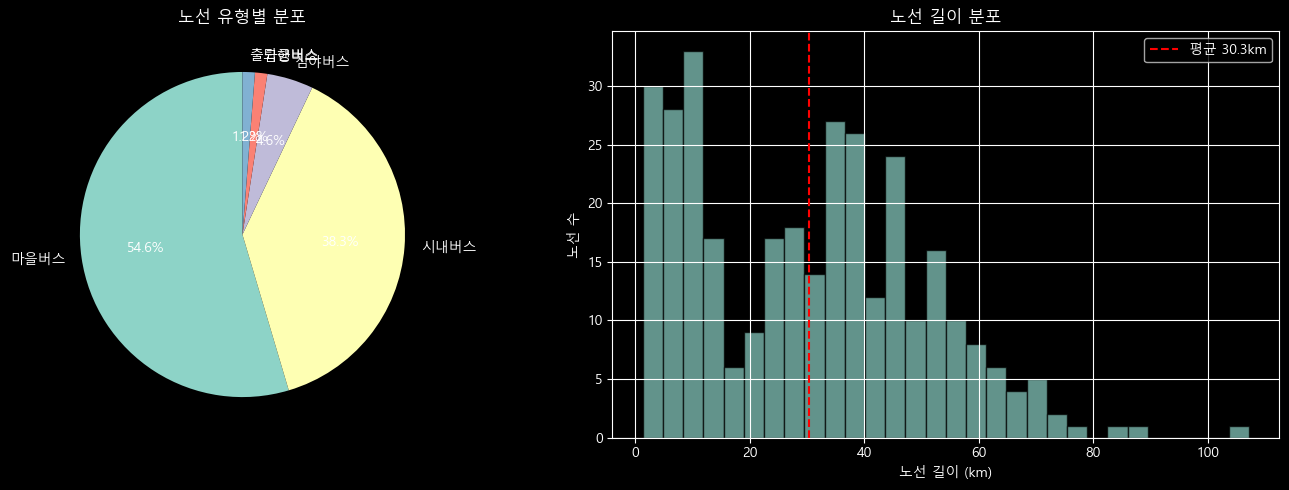

저장: fig_01_route_distribution.png


In [37]:
# 6.1 노선 유형별 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 노선 유형 파이차트
type_counts = route_list['노선유형'].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('노선 유형별 분포')

# 노선 길이 분포
routes_gdf_5179['노선길이_km'].hist(bins=30, ax=axes[1], edgecolor='black', alpha=0.7)
axes[1].set_xlabel('노선 길이 (km)')
axes[1].set_ylabel('노선 수')
axes[1].set_title('노선 길이 분포')
axes[1].axvline(routes_gdf_5179['노선길이_km'].mean(), color='red', linestyle='--', label=f'평균 {routes_gdf_5179["노선길이_km"].mean():.1f}km')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{BASE}/fig_01_route_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: fig_01_route_distribution.png')

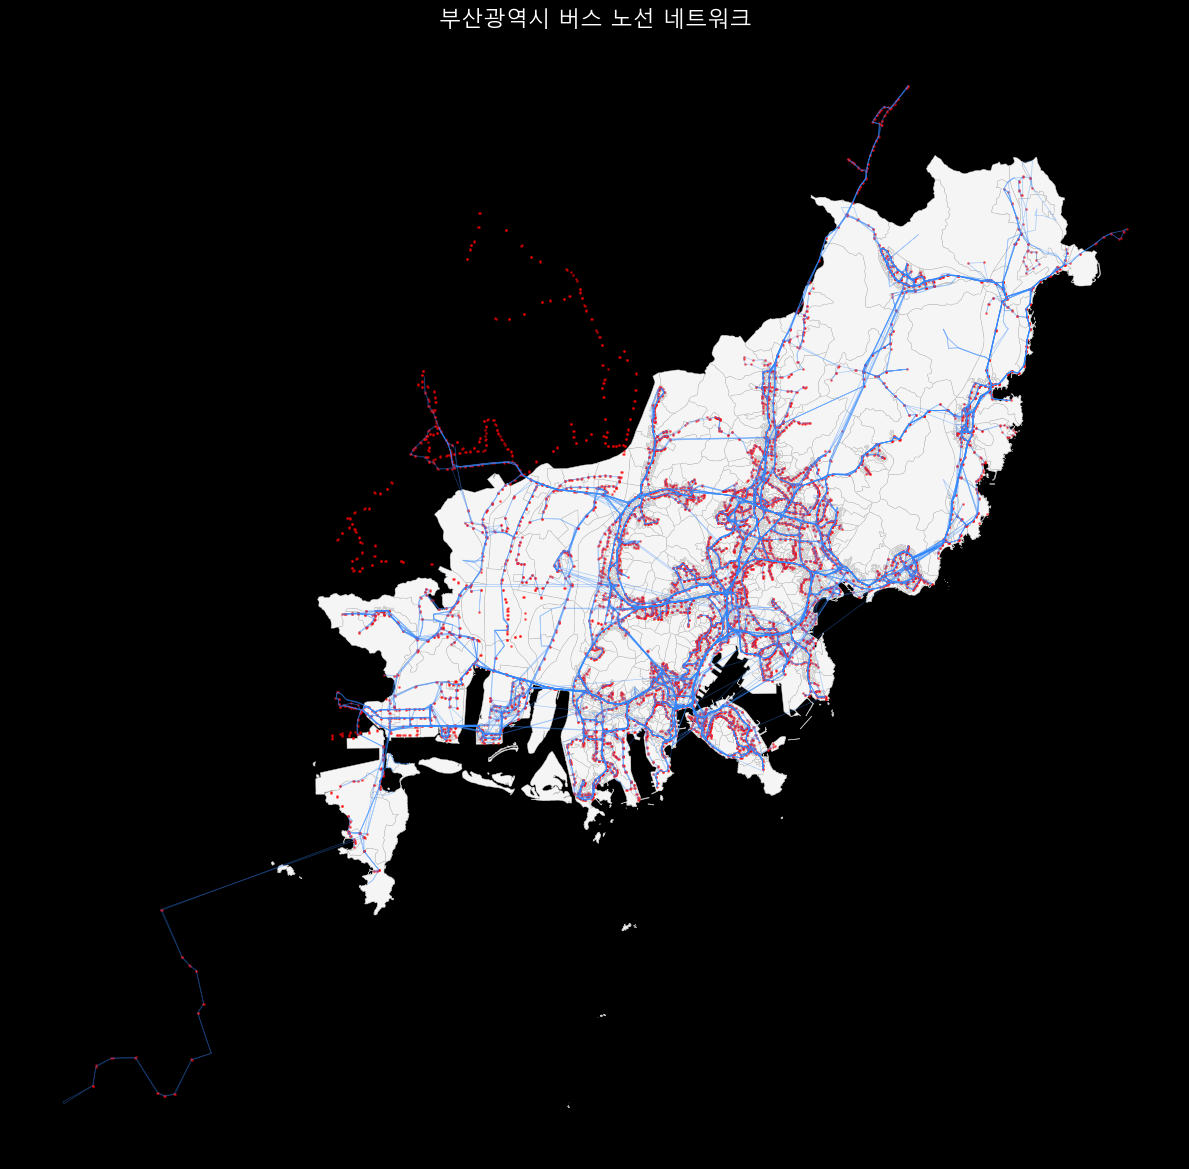

저장: fig_02_route_network.png


In [38]:
# 6.2 버스 노선 네트워크 지도
fig, ax = plt.subplots(1, 1, figsize=(12, 14))

# 집계구 경계 (배경)
census.plot(ax=ax, facecolor='#f5f5f5', edgecolor='#cccccc', linewidth=0.3)

# 노선 경로
routes_gdf_5179.plot(ax=ax, color='#3388ff', linewidth=0.5, alpha=0.4)

# 정류소
bus_stops_shp.plot(ax=ax, color='red', markersize=1, alpha=0.5)

ax.set_title('부산광역시 버스 노선 네트워크', fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(f'{BASE}/fig_02_route_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: fig_02_route_network.png')

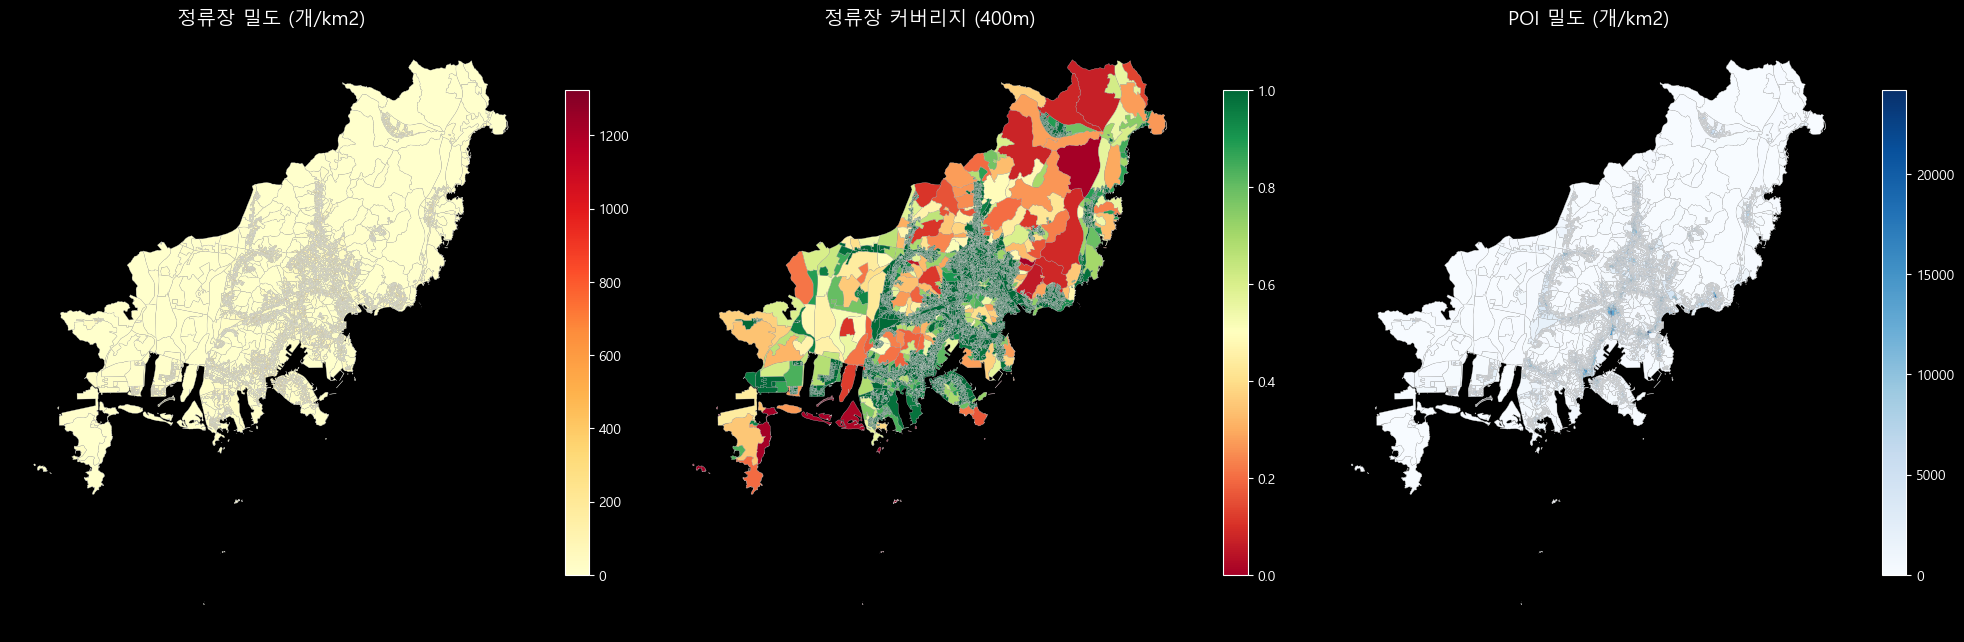

저장: fig_03_supply_indicators.png


In [39]:
# 6.3 정류장 밀도 히트맵 (집계구 단위)
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# 정류장 밀도
census_with_stops.plot(
    column='정류장밀도', ax=axes[0], legend=True,
    cmap='YlOrRd', edgecolor='#cccccc', linewidth=0.2,
    legend_kwds={'shrink': 0.5}
)
axes[0].set_title('정류장 밀도 (개/km2)', fontsize=14)
axes[0].set_axis_off()

# 커버리지
census_with_stops.plot(
    column='커버리지', ax=axes[1], legend=True,
    cmap='RdYlGn', edgecolor='#cccccc', linewidth=0.2,
    legend_kwds={'shrink': 0.5}
)
axes[1].set_title('정류장 커버리지 (400m)', fontsize=14)
axes[1].set_axis_off()

# POI 밀도
census_with_stops.plot(
    column='POI밀도', ax=axes[2], legend=True,
    cmap='Blues', edgecolor='#cccccc', linewidth=0.2,
    legend_kwds={'shrink': 0.5}
)
axes[2].set_title('POI 밀도 (개/km2)', fontsize=14)
axes[2].set_axis_off()

plt.tight_layout()
plt.savefig(f'{BASE}/fig_03_supply_indicators.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: fig_03_supply_indicators.png')

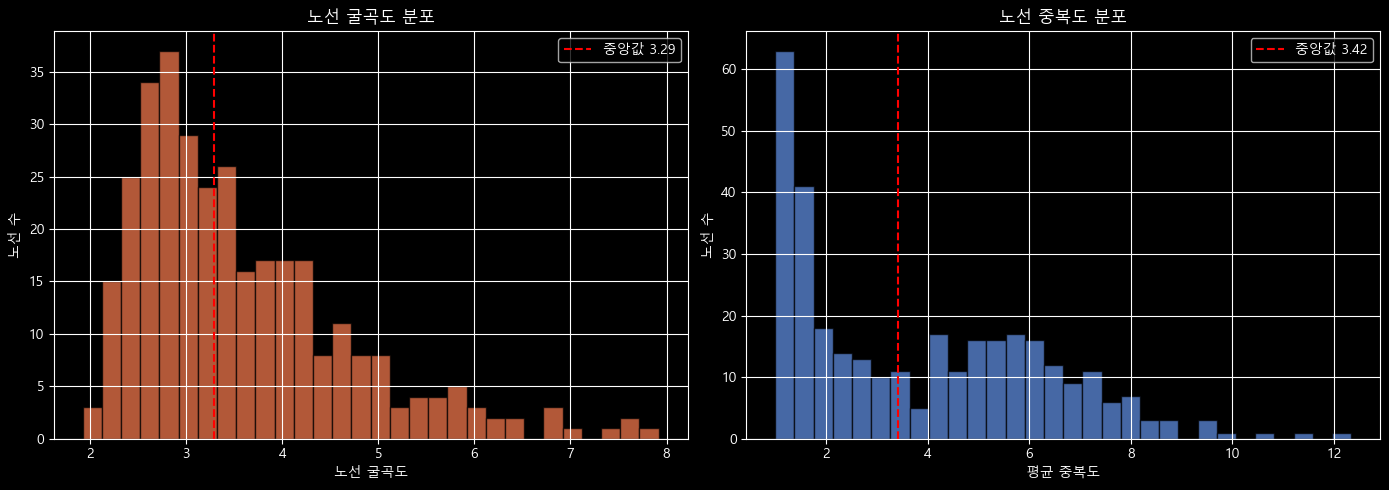

저장: fig_04_sinuosity_overlap.png


In [40]:
# 6.4 노선 굴곡도/중복도 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 굴곡도 분포
routes_gdf_5179['노선굴곡도'].hist(bins=30, ax=axes[0], edgecolor='black', alpha=0.7, color='#ff7f50')
axes[0].set_xlabel('노선 굴곡도')
axes[0].set_ylabel('노선 수')
axes[0].set_title('노선 굴곡도 분포')
axes[0].axvline(routes_gdf_5179['노선굴곡도'].median(), color='red', linestyle='--', label=f'중앙값 {routes_gdf_5179["노선굴곡도"].median():.2f}')
axes[0].legend()

# 중복도 분포
route_overlap['평균중복도'].hist(bins=30, ax=axes[1], edgecolor='black', alpha=0.7, color='#6495ed')
axes[1].set_xlabel('평균 중복도')
axes[1].set_ylabel('노선 수')
axes[1].set_title('노선 중복도 분포')
axes[1].axvline(route_overlap['평균중복도'].median(), color='red', linestyle='--', label=f'중앙값 {route_overlap["평균중복도"].median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{BASE}/fig_04_sinuosity_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: fig_04_sinuosity_overlap.png')

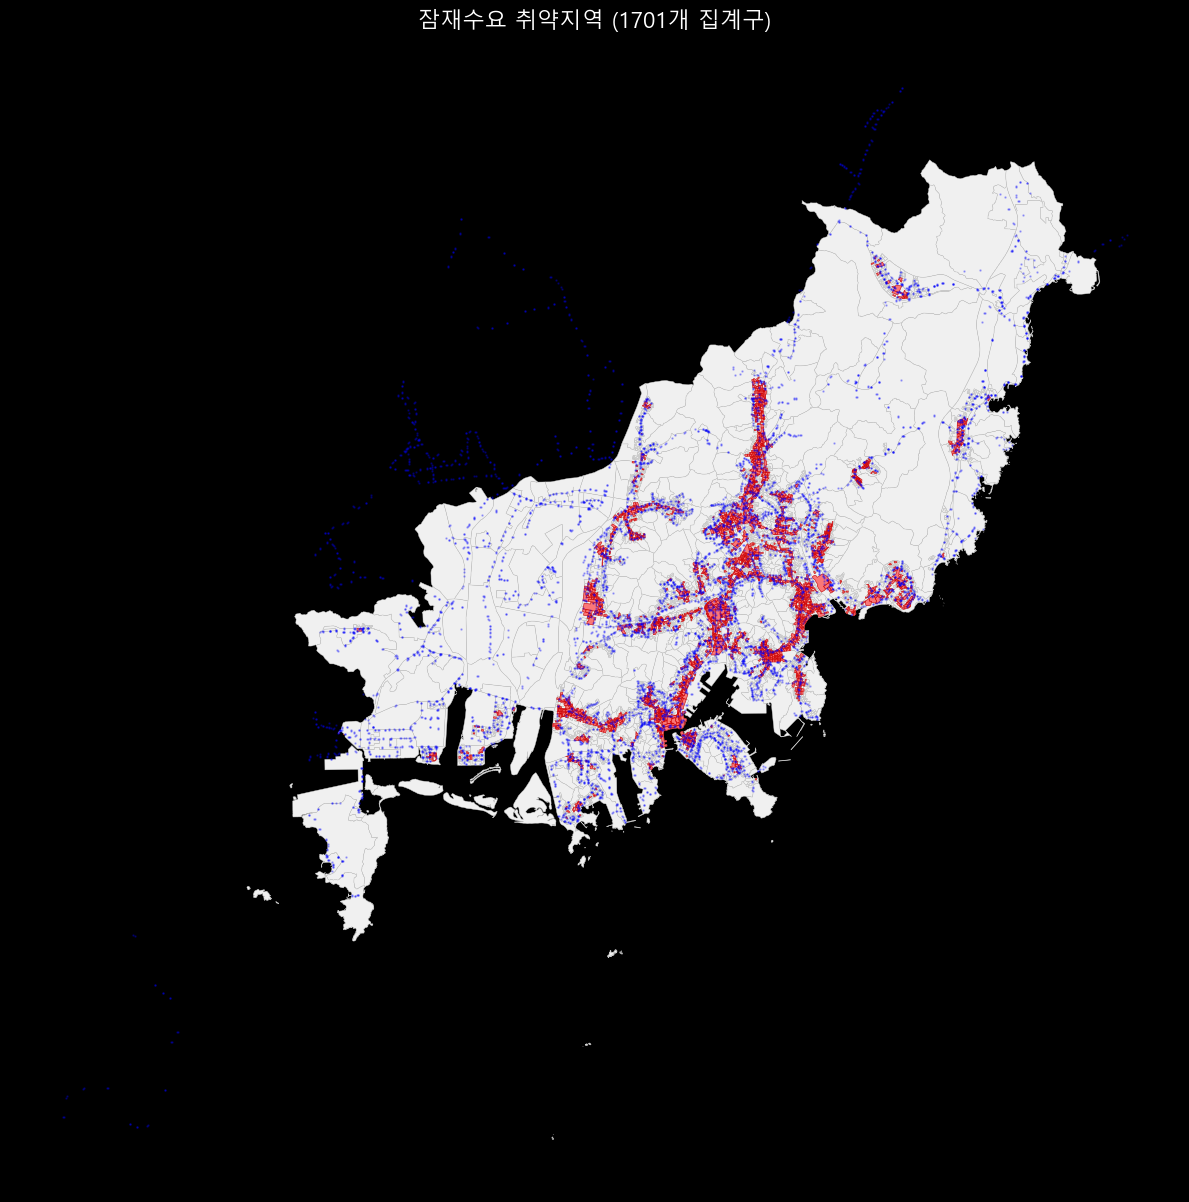

저장: fig_05_vulnerable_areas.png


In [41]:
# 6.5 잠재수요 취약지역 시각화
fig, ax = plt.subplots(1, 1, figsize=(12, 14))

# 전체 집계구 (회색)
census_with_stops.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#cccccc', linewidth=0.3)

# 취약지역 (빨강)
if len(vulnerable) > 0:
    vulnerable.plot(ax=ax, facecolor='#ff4444', edgecolor='#cc0000', linewidth=0.5, alpha=0.7, label='취약지역')

# 정류소 (점)
bus_stops_shp.plot(ax=ax, color='blue', markersize=0.5, alpha=0.3)

ax.set_title(f'잠재수요 취약지역 ({len(vulnerable)}개 집계구)', fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(f'{BASE}/fig_05_vulnerable_areas.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: fig_05_vulnerable_areas.png')

---
## 7. 결과 요약

In [42]:
# 전체 공급지표 요약
print('='*60)
print('부산광역시 대중교통 공급지표 종합 요약')
print('='*60)

print(f'\n[기본 현황]')
print(f'  버스 노선 수: {bus_routes["노선번호"].nunique()}개')
print(f'  버스 정류소 수: {len(bus_stops_shp):,}개')
print(f'  집계구 수: {len(census):,}개')
print(f'  50m 격자 수: {len(grid_50m):,}개')
print(f'  POI 수: {len(poi):,}개')

print(f'\n[노선 분석]')
print(f'  평균 노선 길이: {routes_gdf_5179["노선길이_km"].mean():.1f} km')
print(f'  평균 노선 굴곡도: {routes_gdf_5179["노선굴곡도"].mean():.2f}')
print(f'  평균 노선 중복도: {route_overlap["평균중복도"].mean():.2f}')
print(f'  2개+ 노선 공유 링크: {(link_counts["공유노선수"]>=2).sum():,}개 ({(link_counts["공유노선수"]>=2).mean()*100:.1f}%)')

print(f'\n[공급 지표 (집계구 단위)]')
print(f'  평균 정류장 밀도: {census_with_stops["정류장밀도"].mean():.1f} 개/km2')
print(f'  평균 커버리지: {census_with_stops["커버리지"].mean()*100:.1f}%')
print(f'  정류소 없는 집계구: {(census_with_stops["정류소수"]==0).sum():,}개')

print(f'\n[잠재수요 취약지역]')
print(f'  취약 집계구: {len(vulnerable):,}개')
print(f'  (POI밀도 상위25% & 커버리지 하위25%)')

부산광역시 대중교통 공급지표 종합 요약

[기본 현황]
  버스 노선 수: 326개
  버스 정류소 수: 8,522개
  집계구 수: 6,802개
  50m 격자 수: 310,241개
  POI 수: 487,818개

[노선 분석]
  평균 노선 길이: 30.3 km
  평균 노선 굴곡도: 3.58
  평균 노선 중복도: 3.85
  2개+ 노선 공유 링크: 4,617개 (44.4%)

[공급 지표 (집계구 단위)]
  평균 정류장 밀도: 34.3 개/km2
  평균 커버리지: 97.3%
  정류소 없는 집계구: 4,068개

[잠재수요 취약지역]
  취약 집계구: 1,701개
  (POI밀도 상위25% & 커버리지 하위25%)


In [52]:
# 결과 데이터 저장
# 집계구별 공급지표
export_cols = ['TOT_REG_CD', 'ADM_CD', '시군구코드', '면적_km2', 
               '정류소수', '정류장밀도', '커버리지', '총정차노선수',
               'POI수', '상업시설', '교통시설', '공간시설', '기관', 'POI밀도']
existing_cols = [c for c in export_cols if c in census_with_stops.columns]
census_with_stops[existing_cols].to_csv(f'{BASE}/result_집계구별_공급지표.csv', index=False, encoding='utf-8-sig')
print('저장: result_집계구별_공급지표.csv')

# 노선별 분석 결과
route_analysis = routes_gdf_5179[['노선번호', '정류소수', '노선길이_km', '노선굴곡도']].merge(
    route_overlap, on='노선번호', how='left'
)
route_analysis = route_analysis.merge(route_list[['노선번호','노선유형']], on='노선번호', how='left')
route_analysis.to_csv(f'{BASE}/result_노선별_분석결과.csv', index=False, encoding='utf-8-sig')
print('저장: result_노선별_분석결과.csv')

# 취약지역
if len(vulnerable) > 0:
    vulnerable[existing_cols].to_csv(f'{BASE}/result_잠재수요_취약지역.csv', index=False, encoding='utf-8-sig')
    print('저장: result_잠재수요_취약지역.csv')

print('\n모든 결과 저장 완료!')

저장: result_집계구별_공급지표.csv
저장: result_노선별_분석결과.csv
저장: result_잠재수요_취약지역.csv

모든 결과 저장 완료!


# 7. 신규 심야노선 설계 (기존 노선 중복 제거)

In [53]:
# 7.1 기존 심야버스 노선 정보 추출

# 심야버스 노선 필터링
night_bus_routes = bus_routes[bus_routes['노선유형'] == '심야버스'].copy()

# 기존 심야버스가 서비스하는 정류소 ID 목록
existing_night_stops = set(night_bus_routes['정류소ID'].unique())

print(f'=== 기존 심야버스 현황 ===')
print(f'심야버스 노선 수: {night_bus_routes["노선번호"].nunique()}개')
print(f'심야버스 정류소 수: {len(existing_night_stops)}개')

print(f'\n심야버스 노선 목록:')
print(night_bus_routes[['노선번호']].drop_duplicates().values.flatten())


KeyError: '노선유형'

In [47]:
bus_routes.head()

,노선번호,정류소순번,정류소명,시,군.구,동,GPS_X,GPX_Y,ARS ID,정류소ID
0,10,1,연제공용버스차고지,부산광역시,NaN,NaN,129.053194,35.185229,13179,50000001059
1,10,2,초읍고개,부산광역시,NaN,NaN,129.054089,35.185475,13183,50000002492
2,10,3,개인택시조합,부산광역시,연제구,거제2동,129.055711,35.186786,13132,21130521003
3,10,4,부산의료원 정문,부산광역시,NaN,NaN,129.058971,35.187956,13186,50000003510
4,10,5,부산의료원,부산광역시,연제구,거제2동,129.060579,35.188257,13123,21130521007


In [45]:
# 7.2 기존 심야버스 서비스 권역 (500m 버퍼)

# 정류소명 정규화 (공백 제거)
if 'bstopnm_clean' not in bus_stops_shp.columns:
    bus_stops_shp['bstopnm_clean'] = bus_stops_shp['bstopnm'].str.strip()

if '정류소명_clean' not in night_bus_routes.columns:
    night_bus_routes['정류소명_clean'] = night_bus_routes['정류소명'].str.strip()

# 정류소명으로 매칭 (공백 제거된 이름 사용)
night_stop_names = set(night_bus_routes['정류소명_clean'])

night_bus_stops_gdf = bus_stops_shp[
    bus_stops_shp['bstopnm_clean'].isin(night_stop_names)
].copy()

# 매칭 안되면 bus_routes GPS 좌표로 직접 생성
if len(night_bus_stops_gdf) == 0:
    print('버스 정류소 shp 파일에서 매칭 실패, GPS 좌표로 직접 생성')
    night_coords = night_bus_routes[['정류소명', 'GPS_X', 'GPX_Y']].drop_duplicates('정류소명')
    night_coords = night_coords.dropna(subset=['GPS_X', 'GPX_Y'])

    from shapely.geometry import Point
    night_bus_stops_gdf = gpd.GeoDataFrame(
        night_coords,
        geometry=[Point(row['GPS_X'], row['GPX_Y']) for _, row in night_coords.iterrows()],
        crs='EPSG:4326'
    ).to_crs('EPSG:5179')

# 500m 버퍼 생성 (기존 노선과 중복 판정 기준)
if len(night_bus_stops_gdf) > 0:
    night_bus_buffer = night_bus_stops_gdf.copy()
    night_bus_buffer['geometry'] = night_bus_buffer.buffer(500)  # 500m 버퍼
    night_service_area = night_bus_buffer.unary_union  # 모든 버퍼 통합

    print(f'=== 기존 심야버스 서비스 권역 ===')
    print(f'기존 심야버스 정류소: {len(night_bus_stops_gdf)}개')
    print(f'서비스 권역 면적: {night_service_area.area / 1_000_000:.2f} km²')
else:
    print('ERROR: 기존 심야버스 정류소를 찾을 수 없습니다.')
    night_service_area = None


NameError: name 'night_bus_routes' is not defined

In [ ]:
# 7.3 신규 노선 후보지역 선정 (기존 노선과 비중복)
# night_vulnerable: 상업시설 많으나 심야수요 적은 집계구 (419개)

# 각 집계구 중심점 생성
night_vulnerable_copy = night_vulnerable.copy()
night_vulnerable_copy['centroid'] = night_vulnerable_copy.geometry.centroid

# 기존 심야버스 서비스 권역과 겹치지 않는 집계구 필터링
def is_not_overlapping(geom):
    return not geom.intersects(night_service_area)

new_candidates = night_vulnerable_copy[
    night_vulnerable_copy['geometry'].apply(is_not_overlapping)
].copy()

print(f'=== 신규 노선 후보지역 (기존 노선 제외) ===')
print(f'전체 후보: {len(night_vulnerable)}개')
print(f'기존 노선 중복 제거: {len(new_candidates)}개')
print(f'제거된 집계구: {len(night_vulnerable) - len(new_candidates)}개')

# 상위 20개 출력
if len(new_candidates) > 0:
    print(f'\n신규 후보 상위 20 (상업시설 기준):')
    print(new_candidates.nlargest(20, '상업시설')[['TOT_REG_CD', '상업시설', '심야수요', '정류소수', '커버리지']])

In [ ]:
# 7.4 후보지역 클러스터링 (공간적으로 인접한 지역 묶기)
from sklearn.cluster import DBSCAN

if len(new_candidates) > 0:
    # 집계구 중심점 좌표 추출
    coords = np.array([[geom.x, geom.y] for geom in new_candidates['centroid']])
    
    # DBSCAN 클러스터링 (eps=2000m, min_samples=3)
    clustering = DBSCAN(eps=2000, min_samples=3).fit(coords)
    new_candidates['cluster'] = clustering.labels_
    
    # 클러스터별 통계
    cluster_stats = new_candidates[new_candidates['cluster'] >= 0].groupby('cluster').agg(
        집계구수=('TOT_REG_CD', 'count'),
        총상업시설=('상업시설', 'sum'),
        총심야수요=('심야수요', 'sum'),
        평균정류소수=('정류소수', 'mean')
    ).sort_values('총상업시설', ascending=False)
    
    print(f'=== 후보지역 클러스터링 결과 ===')
    print(f'클러스터 수: {clustering.labels_.max() + 1}개')
    print(f'노이즈 포인트: {(clustering.labels_ == -1).sum()}개')
    print(f'\n클러스터별 통계:')
    print(cluster_stats)
else:
    print('신규 후보지역이 없습니다.')

In [ ]:
# 7.5 주요 환승 거점 선정 (시작점/종점 후보)
# 심야 승차량 상위 지하철역 (night_station 활용)
# 지하철역만 필터링
subway_stations = night_station[night_station['station_name'].str.contains('지하철', na=False)].copy()
major_hubs = subway_stations.nlargest(15, '심야승차량')

print(f'=== 주요 심야 환승 거점 (Top 15) ===')
print(major_hubs[['station_name', '심야승차량']])

# 환승거점 좌표 매핑
major_hubs_clean = major_hubs.copy()
major_hubs_clean['station_name_clean'] = major_hubs_clean['station_name'].str.strip()

# bus_routes에서 좌표 가져오기
hub_coords = major_hubs_clean.merge(
    routes_coords,
    left_on='station_name_clean',
    right_on='정류소명_clean',
    how='left'
)

print(f'\n좌표 매핑 결과: {hub_coords["GPS_X"].notna().sum()}/{len(hub_coords)}')

In [ ]:
# 7.6 신규 노선 경로 설계 (클러스터별 + 최근접 환승거점 연결)
from scipy.spatial import distance_matrix
from scipy.spatial.distance import cdist

if len(new_candidates) > 0 and 'cluster' in new_candidates.columns and new_candidates['cluster'].max() >= 0:
    
    # 각 클러스터별로 노선 설계
    new_routes = []
    
    for cluster_id in range(new_candidates['cluster'].max() + 1):
        cluster_areas = new_candidates[new_candidates['cluster'] == cluster_id].copy()
        
        if len(cluster_areas) < 3:
            continue
        
        # 클러스터 중심점 계산
        cluster_center = cluster_areas['centroid'].unary_union.centroid
        
        # 가장 가까운 환승 거점 찾기 (좌표 있는 것만)
        hub_with_coords = hub_coords[hub_coords['GPS_X'].notna()].copy()
        
        if len(hub_with_coords) > 0:
            # 환승 거점들의 EPSG:5179 좌표 (bus_routes는 GPS 좌표이므로 변환 필요)
            hub_points = gpd.GeoDataFrame(
                hub_with_coords,
                geometry=[Point(row['GPS_X'], row['GPX_Y']) for _, row in hub_with_coords.iterrows()],
                crs='EPSG:4326'
            ).to_crs('EPSG:5179')
            
            # 클러스터 중심에서 가장 가까운 환승거점
            distances = [cluster_center.distance(pt) for pt in hub_points.geometry]
            nearest_hub_idx = np.argmin(distances)
            nearest_hub = hub_with_coords.iloc[nearest_hub_idx]
            
            route_info = {
                '클러스터ID': cluster_id,
                '집계구수': len(cluster_areas),
                '총상업시설': cluster_areas['상업시설'].sum(),
                '총심야수요': cluster_areas['심야수요'].sum(),
                '환승거점': nearest_hub['station_name'],
                '거점거리_km': distances[nearest_hub_idx] / 1000,
                '클러스터중심_x': cluster_center.x,
                '클러스터중심_y': cluster_center.y
            }
            
            new_routes.append(route_info)
    
    # 결과 출력
    if new_routes:
        routes_df = pd.DataFrame(new_routes)
        routes_df = routes_df.sort_values('총상업시설', ascending=False)
        
        print(f'=== 신규 심야노선 설계 결과 ===')
        print(f'총 {len(routes_df)}개 노선 제안\n')
        print(routes_df[['클러스터ID', '집계구수', '총상업시설', '총심야수요', '환승거점', '거점거리_km']])
        
        # CSV 저장
        routes_df.to_csv(f'{BASE}/result_신규심야노선_제안.csv', index=False, encoding='utf-8-sig')
        print(f'\n저장: result_신규심야노선_제안.csv')
    else:
        print('설계 가능한 노선이 없습니다.')
else:
    print('클러스터링 결과가 없어 노선 설계를 수행할 수 없습니다.')

In [ ]:
# 7.7 신규 노선 시각화
if len(new_candidates) > 0 and 'cluster' in new_candidates.columns:
    fig, ax = plt.subplots(1, 1, figsize=(14, 16))
    
    # 배경: 전체 집계구
    census.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.3, alpha=0.5)
    
    # 기존 심야버스 서비스 권역
    if night_service_area is not None and not night_service_area.is_empty:
        gpd.GeoSeries([night_service_area], crs='EPSG:5179').plot(
            ax=ax, color='yellow', alpha=0.2, edgecolor='orange', linewidth=1.5, label='기존 심야버스 권역 (500m)'
        )
    
    # 신규 후보지역 (클러스터별 색상)
    cluster_handles = []
    if new_candidates['cluster'].max() >= 0:
        clusters = new_candidates[new_candidates['cluster'] >= 0]
        
        # 클러스터별로 그리고 범례 핸들 생성
        from matplotlib.patches import Patch
        import matplotlib.cm as cm
        
        n_clusters = clusters['cluster'].nunique()
        colors = cm.tab10(range(n_clusters))
        
        for idx, cluster_id in enumerate(sorted(clusters['cluster'].unique())):
            cluster_data = clusters[clusters['cluster'] == cluster_id]
            color = colors[idx % 10]
            
            cluster_data.plot(
                ax=ax, color=color, edgecolor='black', linewidth=0.8, alpha=0.7
            )
            
            # 범례 핸들 추가
            cluster_handles.append(
                Patch(facecolor=color, edgecolor='black', label=f'클러스터 {cluster_id} ({len(cluster_data)}개)')
            )
    
    # 노이즈 포인트 (클러스터 미포함)
    noise = new_candidates[new_candidates['cluster'] == -1]
    if len(noise) > 0:
        noise.plot(ax=ax, color='red', edgecolor='darkred', linewidth=0.5, alpha=0.5)
        from matplotlib.patches import Patch
        cluster_handles.append(
            Patch(facecolor='red', edgecolor='darkred', label=f'비클러스터 지역 ({len(noise)}개)')
        )
    
    # 환승 거점
    if len(hub_coords[hub_coords['GPS_X'].notna()]) > 0:
        hub_gdf = gpd.GeoDataFrame(
            hub_coords[hub_coords['GPS_X'].notna()],
            geometry=[Point(row['GPS_X'], row['GPX_Y']) for _, row in hub_coords[hub_coords['GPS_X'].notna()].iterrows()],
            crs='EPSG:4326'
        ).to_crs('EPSG:5179')
        
        hub_gdf.plot(ax=ax, color='blue', marker='*', markersize=200, 
                     edgecolor='white', linewidth=1.5, zorder=5)
        
        # 환승 거점 범례
        from matplotlib.lines import Line2D
        hub_handle = Line2D([0], [0], marker='*', color='w', markerfacecolor='blue', 
                           markeredgecolor='white', markersize=15, label=f'환승 거점 ({len(hub_gdf)}개)')
        cluster_handles.append(hub_handle)
    
    ax.set_title('신규 심야노선 후보지역 및 환승거점', fontsize=16, fontweight='bold', pad=20)
    
    # 범례 설정
    if cluster_handles:
        ax.legend(handles=cluster_handles, loc='upper right', fontsize=9, 
                 framealpha=0.9, title='범례', title_fontsize=10)
    
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.savefig(f'{BASE}/fig_06_new_night_routes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: fig_06_new_night_routes.png')
else:
    print('시각화할 데이터가 없습니다.')

# 7. 신규 심야노선 설계 (기존 노선 중복 제거)

In [ ]:
# 7.1 기존 심야버스 노선 정보 추출

# 심야버스 노선 필터링
night_bus_routes = bus_routes[bus_routes["노선유형"] == "심야버스"].copy()

# 기존 심야버스가 서비스하는 정류소 ID 목록
existing_night_stops = set(night_bus_routes["정류소ID"].unique())

print(f"=== 기존 심야버스 현황 ===")
print(f"심야버스 노선 수: {night_bus_routes["노선번호"].nunique()}개")
print(f"심야버스 정류소 수: {len(existing_night_stops)}개")

print(f"
심야버스 노선 목록:")
print(night_bus_routes[["노선번호"]].drop_duplicates().values.flatten())

In [ ]:
# 7.2 기존 심야버스 서비스 권역 (500m 버퍼)
# 기존 심야버스 정류소 geometry 얻기
night_bus_stops_gdf = bus_stops_shp[
    bus_stops_shp['bstopid'].astype(str).isin([str(x) for x in existing_night_stops])
].copy()

# 500m 버퍼 생성 (기존 노선과 중복 판정 기준)
night_bus_buffer = night_bus_stops_gdf.copy()
night_bus_buffer['geometry'] = night_bus_buffer.buffer(500)  # 500m 버퍼
night_service_area = night_bus_buffer.unary_union  # 모든 버퍼 통합

print(f'=== 기존 심야버스 서비스 권역 ===')
print(f'기존 심야버스 정류소: {len(night_bus_stops_gdf)}개')
print(f'서비스 권역 면적: {night_service_area.area / 1_000_000:.2f} km²')

In [ ]:
# 7.3 신규 노선 후보지역 선정 (기존 노선과 비중복)
# night_vulnerable: 상업시설 많으나 심야수요 적은 집계구 (419개)

# 각 집계구 중심점 생성
night_vulnerable_copy = night_vulnerable.copy()
night_vulnerable_copy['centroid'] = night_vulnerable_copy.geometry.centroid

# 기존 심야버스 서비스 권역과 겹치지 않는 집계구 필터링
def is_not_overlapping(geom):
    return not geom.intersects(night_service_area)

new_candidates = night_vulnerable_copy[
    night_vulnerable_copy['geometry'].apply(is_not_overlapping)
].copy()

print(f'=== 신규 노선 후보지역 (기존 노선 제외) ===')
print(f'전체 후보: {len(night_vulnerable)}개')
print(f'기존 노선 중복 제거: {len(new_candidates)}개')
print(f'제거된 집계구: {len(night_vulnerable) - len(new_candidates)}개')

# 상위 20개 출력
if len(new_candidates) > 0:
    print(f'\n신규 후보 상위 20 (상업시설 기준):')
    print(new_candidates.nlargest(20, '상업시설')[['TOT_REG_CD', '상업시설', '심야수요', '정류소수', '커버리지']])

In [ ]:
# 7.4 후보지역 클러스터링 (공간적으로 인접한 지역 묶기)
from sklearn.cluster import DBSCAN

if len(new_candidates) > 0:
    # 집계구 중심점 좌표 추출
    coords = np.array([[geom.x, geom.y] for geom in new_candidates['centroid']])
    
    # DBSCAN 클러스터링 (eps=2000m, min_samples=3)
    clustering = DBSCAN(eps=2000, min_samples=3).fit(coords)
    new_candidates['cluster'] = clustering.labels_
    
    # 클러스터별 통계
    cluster_stats = new_candidates[new_candidates['cluster'] >= 0].groupby('cluster').agg(
        집계구수=('TOT_REG_CD', 'count'),
        총상업시설=('상업시설', 'sum'),
        총심야수요=('심야수요', 'sum'),
        평균정류소수=('정류소수', 'mean')
    ).sort_values('총상업시설', ascending=False)
    
    print(f'=== 후보지역 클러스터링 결과 ===')
    print(f'클러스터 수: {clustering.labels_.max() + 1}개')
    print(f'노이즈 포인트: {(clustering.labels_ == -1).sum()}개')
    print(f'\n클러스터별 통계:')
    print(cluster_stats)
else:
    print('신규 후보지역이 없습니다.')

In [ ]:
# 7.5 클러스터별 대표 버스 정류소 선정# 각 클러스터의 중심에 가장 가까운 버스 정류소 찾기cluster_stops = []for cluster_id in sorted(new_candidates['cluster'].unique()):    if cluster_id == -1:  # 노이즈 제외        continue    cluster_data = new_candidates[new_candidates['cluster'] == cluster_id]    cluster_center = cluster_data['centroid'].unary_union.centroid    # 클러스터 내 집계구들과 인접한 버스 정류소 찾기    # buffer를 이용해 클러스터 영역 생성    cluster_area = cluster_data.unary_union.buffer(500)  # 500m 버퍼    # 해당 영역 내의 버스 정류소 찾기    stops_in_cluster = bus_stops_shp[bus_stops_shp.intersects(cluster_area)].copy()    if len(stops_in_cluster) > 0:        # 클러스터 중심에서 가장 가까운 정류소 3개 선정        stops_in_cluster['dist_to_center'] = stops_in_cluster.geometry.distance(cluster_center)        top_stops = stops_in_cluster.nsmallest(3, 'dist_to_center')        cluster_stops.append({            '클러스터ID': cluster_id,            '집계구수': len(cluster_data),            '총상업시설': cluster_data['상업시설'].sum(),            '총심야수요': cluster_data['심야수요'].sum(),            '대표정류소수': len(top_stops),            '중심좌표_x': cluster_center.x,            '중심좌표_y': cluster_center.y,            '대표정류소': list(top_stops['bstopnm'].values),            '정류소좌표': list(zip(top_stops.geometry.x, top_stops.geometry.y))        })cluster_summary = pd.DataFrame(cluster_stops)cluster_summary = cluster_summary.sort_values('총상업시설', ascending=False)print(f'=== 클러스터별 대표 정류소 ===')print(f'총 {len(cluster_summary)}개 클러스터\n')print(cluster_summary[['클러스터ID', '집계구수', '총상업시설', '총심야수요', '대표정류소수']])# 심야 이용이 많은 버스 정류소 (환승 거점용)bus_night_stops = night_station[~night_station['station_name'].str.contains('지하철', na=False)].copy()bus_night_stops = bus_night_stops.nlargest(20, '심야승차량')print(f'\n=== 심야 이용 상위 버스 정류소 (Top 20) ===')print(bus_night_stops[['station_name', '심야승차량']].head(10))

In [ ]:
# 7.6 신규 노선 설계 (클러스터 연결형)# 방식: 각 클러스터의 대표 정류소들을 연결하여 순환 노선 설계# 큰 클러스터들을 우선적으로 연결if len(cluster_summary) > 0:    new_routes = []    # 방법 1: 각 클러스터를 독립 노선으로 설계 (클러스터당 1개 노선)    for idx, cluster_info in cluster_summary.iterrows():        cluster_id = cluster_info['클러스터ID']        # 클러스터가 일정 규모 이상인 경우만 노선 제안        if cluster_info['집계구수'] >= 3:            route_info = {                '노선ID': f'신규심야{cluster_id+1}',                '클러스터ID': cluster_id,                '집계구수': cluster_info['집계구수'],                '총상업시설': cluster_info['총상업시설'],                '총심야수요': cluster_info['총심야수요'],                '경유정류소수': cluster_info['대표정류소수'],                '대표정류소': ', '.join(cluster_info['대표정류소'][:3]),                '노선유형': '클러스터순환형'            }            new_routes.append(route_info)    # 방법 2: 인접한 클러스터들을 묶어서 노선 설계    # (클러스터 간 거리가 5km 이내인 경우 하나의 노선으로 통합)    if len(cluster_summary) >= 2:        from scipy.spatial.distance import cdist        # 클러스터 중심 좌표        centers = cluster_summary[['중심좌표_x', '중심좌표_y']].values        # 클러스터 간 거리 행렬        dist_matrix = cdist(centers, centers, metric='euclidean')        # 거리 5km 이내 클러스터 그룹핑        threshold = 5000  # 5km        cluster_groups = []        visited = set()        for i in range(len(cluster_summary)):            if i in visited:                continue            # i번째 클러스터와 가까운 클러스터들 찾기            group = [i]            visited.add(i)            for j in range(len(cluster_summary)):                if j != i and j not in visited and dist_matrix[i][j] < threshold:                    group.append(j)                    visited.add(j)            if len(group) >= 1:                cluster_groups.append(group)        # 그룹별 통합 노선 제안        for g_idx, group in enumerate(cluster_groups):            group_clusters = cluster_summary.iloc[group]            total_areas = group_clusters['집계구수'].sum()            total_commercial = group_clusters['총상업시설'].sum()            total_demand = group_clusters['총심야수요'].sum()            if total_areas >= 5:  # 충분한 규모                route_info = {                    '노선ID': f'신규심야통합{g_idx+1}',                    '클러스터ID': f"C{'+'.join(map(str, group_clusters['클러스터ID'].values))}",                    '집계구수': total_areas,                    '총상업시설': total_commercial,                    '총심야수요': total_demand,                    '경유정류소수': group_clusters['대표정류소수'].sum(),                    '대표정류소': '다수',                    '노선유형': '클러스터연결형'                }                new_routes.append(route_info)    # 결과 출력    if new_routes:        routes_df = pd.DataFrame(new_routes)        routes_df = routes_df.sort_values('총상업시설', ascending=False)        print(f'=== 신규 심야노선 설계 결과 ===')        print(f'총 {len(routes_df)}개 노선 제안\n')        print(routes_df[['노선ID', '집계구수', '총상업시설', '총심야수요', '노선유형']])        # CSV 저장        routes_df.to_csv(f'{BASE}/result_신규심야노선_제안.csv', index=False, encoding='utf-8-sig')        print(f'\n저장: result_신규심야노선_제안.csv')    else:        print('설계 가능한 노선이 없습니다.')else:    print('클러스터 데이터가 없습니다.')

In [ ]:
# 7.7 신규 노선 시각화
if len(new_candidates) > 0 and 'cluster' in new_candidates.columns:
    fig, ax = plt.subplots(1, 1, figsize=(14, 16))
    
    # 배경: 전체 집계구
    census.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.3, alpha=0.5)
    
    # 기존 심야버스 서비스 권역
    gpd.GeoSeries([night_service_area], crs='EPSG:5179').plot(
        ax=ax, color='yellow', alpha=0.2, edgecolor='orange', linewidth=1.5, label='기존 심야버스 권역'
    )
    
    # 신규 후보지역 (클러스터별 색상)
    if new_candidates['cluster'].max() >= 0:
        clusters = new_candidates[new_candidates['cluster'] >= 0]
        clusters.plot(
            ax=ax, column='cluster', cmap='tab10', 
            edgecolor='black', linewidth=0.8, alpha=0.7, legend=False
        )
    
    # 노이즈 포인트 (클러스터 미포함)
    noise = new_candidates[new_candidates['cluster'] == -1]
    if len(noise) > 0:
        noise.plot(ax=ax, color='red', edgecolor='darkred', linewidth=0.5, alpha=0.5, label='비클러스터 지역')
    
    # 환승 거점
    if len(hub_coords[hub_coords['GPS_X'].notna()]) > 0:
        hub_gdf = gpd.GeoDataFrame(
            hub_coords[hub_coords['GPS_X'].notna()],
            geometry=[Point(row['GPS_X'], row['GPX_Y']) for _, row in hub_coords[hub_coords['GPS_X'].notna()].iterrows()],
            crs='EPSG:4326'
        ).to_crs('EPSG:5179')
        
        hub_gdf.plot(ax=ax, color='blue', marker='*', markersize=200, 
                     edgecolor='white', linewidth=1.5, label='환승 거점', zorder=5)
    
    ax.set_title('신규 심야노선 후보지역 및 환승거점', fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.savefig(f'{BASE}/fig_06_new_night_routes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: fig_06_new_night_routes.png')
else:
    print('시각화할 데이터가 없습니다.')